In [1]:
import data_preparation
import models
import hydra 
from hydra import compose, initialize
import torch 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import os
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [2]:
initialize(version_base=None, config_path="../config")
cfg = compose(config_name="train_general.yaml", overrides=['dataset=climsim_from_npy', 'model=squeezeformer', 'testing=ft'])
print(cfg.dataset)
print(cfg.model)

{'dataset_name': 'climsim_from_npy', 'input_dim': 94, 'output_dim': 98, 'levels': 45, 'normalize': True, 'target_group': '${target_group}', 'data_dir': '/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/', 'input_file': 'input.npy', 'target_file': 'target.npy', 'output_scale_file_path': '/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc', 'v1_targets': ['ptend_t', 'ptend_q0001', 'cam_out_NETSW', 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD'], 'split': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'dataset_testing_sample_rates': {'quick': 10000, 'reduced': 100, 'full': 7}, 'group_method': 'group_by_months', 'group_by_months': {'num_groups': 4, 'target_group': '${target_group}', 'groups': {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}, 'test_group': {'SON': None}, 'val_group': {'SON': None}}, 'general_dataset_config': {'num_workers': '${testing.num_workers}', 'persistent_wo

# Performance Analysis 002

Continuing on with generally trying to understand why these models fail to generalise. I am starting a new notebook for a. a test of reproducability and b. the previous notebook was getting very long!

Continuing with where we left off - I want to understand more about my efforts to see how 'in domain' related to error 

## Setup

In [3]:
def reshape_to_standard_format(x: np.ndarray) -> np.ndarray:
        """
        Reshapes the output to standard format (batch, variables) from (batch, levels, features)
        Args:
            x: (torch.Tensor) (batch, levels, features) output data from the model
        Returns:
            reshaped_x: (torch.Tensor) (batch, features) reshaped output data
        """

        first_two = x[:, :, 0:2].transpose(0, 2, 1).reshape(x.shape[0], -1)
        means_2_to_9 = x[:, :, 2:10].mean(axis=1)

        # concatenate once
        output = np.concatenate([first_two, means_2_to_9], axis=1)
        return output


In [4]:
path_to_data = '/work/scratch-pw5/bradlesc/climsim/temp/p2.1.4.9_analysis/'
!ls {path_to_data}

train_group_MAM  train_group_SON


In [5]:
# SON trained model
#   JJA test set
# son_trained_jja_test = np.load(os.path.join(path_to_data, 'train_group_SON', 'JJA_test_inputs.npy'))
# son_trained_jja_preds = np.load(os.path.join(path_to_data, 'train_group_SON', 'JJA_test_outputs.npy'))
# son_trained_jja_targs = np.load(os.path.join(path_to_data, 'train_group_SON', 'JJA_test_targets.npy'))

#   SON test set
son_trained_son_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_inputs.npy')))
son_trained_son_preds = np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_outputs.npy'))
son_trained_son_targs = np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_targets.npy'))
son_trained_abs_error = np.abs(son_trained_son_preds - son_trained_son_targs)

# MAM trained model

#   SON test set
mam_trained_son_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_inputs.npy')))
mam_trained_son_preds = np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_outputs.npy'))
mam_trained_son_targs = np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_targets.npy'))
mam_trained_abs_error = np.abs(mam_trained_son_preds - mam_trained_son_targs)


nson, nvar = son_trained_son_targs.shape


In [6]:
son_trained_RMSE = np.sqrt(((son_trained_son_preds - son_trained_son_targs) ** 2).mean(axis=0))
mam_trained_RMSE = np.sqrt(((mam_trained_son_preds - mam_trained_son_targs) ** 2).mean(axis=0))

son_trained_norm_RMSE = son_trained_RMSE / (son_trained_son_targs.max(axis=0) - son_trained_son_targs.min(axis=0))
mam_trained_norm_RMSE = mam_trained_RMSE / (mam_trained_son_targs.max(axis=0) - mam_trained_son_targs.min(axis=0))

print("SON trained model on SON test set average normalized RMSE: ", son_trained_norm_RMSE.mean())
print("MAM trained model on SON test set average normalized RMSE: ", mam_trained_norm_RMSE.mean())
print(son_trained_norm_RMSE.shape)

SON trained model on SON test set average normalized RMSE:  0.023957016
MAM trained model on SON test set average normalized RMSE:  0.025646202
(98,)


Great, I think weve got some data! lets play around with it, lets start by comparing how the two models compare

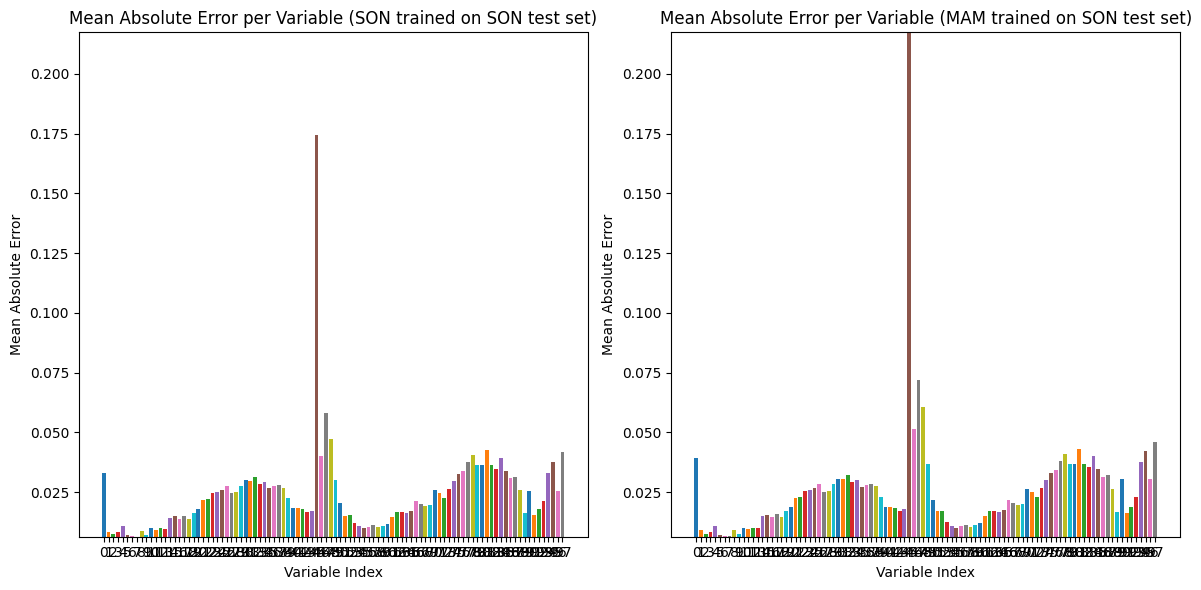

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
vmax = max(np.max(son_trained_norm_RMSE), np.max(mam_trained_norm_RMSE))
vmin = min(np.min(son_trained_norm_RMSE), np.min(mam_trained_norm_RMSE))
for i in range(nvar):
    axes[0].bar(i, son_trained_norm_RMSE[i], label=f'Var {i}')
    axes[1].bar(i, mam_trained_norm_RMSE[i], label=f'Var {i}')
axes[0].set_ylim([vmin, vmax])
axes[1].set_ylim([vmin, vmax])

axes[0].set_title('Mean Absolute Error per Variable (SON trained on SON test set)')
axes[0].set_xlabel('Variable Index')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_xticks(range(nvar))
axes[0].set_xticklabels([str(i) for i in range(nvar)])
# axes[0].legend()
axes[1].set_title('Mean Absolute Error per Variable (MAM trained on SON test set)')
axes[1].set_xlabel('Variable Index')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_xticks(range(nvar))
axes[1].set_xticklabels([str(i) for i in range(nvar)])
# axes[1].legend()
plt.tight_layout()
plt.show()


Ok great, it looks imediatly like the larger error is caused by the lower down air temps, but I should remember the errors for different variables may not be comparable? Lets have a look at the differences between the two

In [8]:
mam_trained_abs_error.shape

(287540, 98)

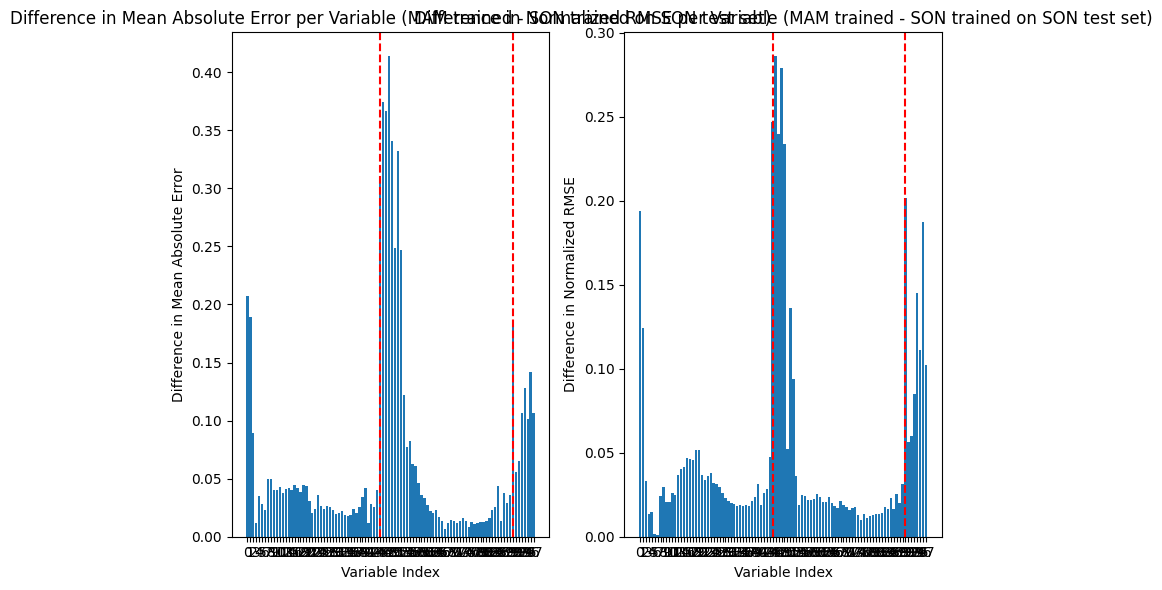

In [9]:
differences = (mam_trained_abs_error.mean(axis=0) - son_trained_abs_error.mean(axis=0)) / son_trained_abs_error.mean(axis=0)
norm_rmse_differences = (mam_trained_norm_RMSE - son_trained_norm_RMSE) / son_trained_norm_RMSE
vmax = np.max([differences, norm_rmse_differences])
vmin = np.min([differences, norm_rmse_differences])


fig, ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].bar(range(nvar), differences)
# ax[0].set_ylim([vmin, vmax])
ax[0].set_title('Difference in Mean Absolute Error per Variable (MAM trained - SON trained on SON test set)')
ax[0].set_xlabel('Variable Index')
ax[0].set_ylabel('Difference in Mean Absolute Error')
ax[0].set_xticks(range(nvar))
ax[0].set_xticklabels([str(i) for i in range(nvar)])
ax[0].axvline(x=90, color='r', linestyle='--', label='95 Variables')
ax[0].axvline(x=45, color='r', linestyle='--', label='95 Variables')

ax[1].bar(range(nvar), norm_rmse_differences)
# ax[1].set_ylim([vmin, vmax])
ax[1].set_title('Difference in Normalized RMSE per Variable (MAM trained - SON trained on SON test set)')
ax[1].set_xlabel('Variable Index')
ax[1].set_ylabel('Difference in Normalized RMSE')
ax[1].set_xticks(range(nvar))
ax[1].set_xticklabels([str(i) for i in range(nvar)])
ax[1].axvline(x=90, color='r', linestyle='--', label='95 Variables')
ax[1].axvline(x=45, color='r', linestyle='--', label='95 Variables')

plt.tight_layout()
plt.show()

Oooh ok super interesting, so when comparing two models one trained on MAM and the other trained on SON, we see a very different 'importance' about the error when we look through different lenses:

### Option 1: Absolute errors:
- the majority of difference in error in the fluxes! With some lower altitude air temperatures involved as well 

### Option 2: Normalised RMSE
- the majority is in the high altitude air temperatures 

Now I have several thoughts:

1. I hate to say it but, what are we trying to optimise for? I belive the MSE will look a lot more like the one on the left than the one on the right. And so if we are trying to optimise for overall model error, then yeah we should probably try and concentrate on the locations that are more influential. But if we want to perhaps be more accurate across the board then maybe the normalised option is important.
2. From a physics point of view, I think we care a lot less about the high altitudes than we do about the fluxes and so on - so perhaps its more important to get these correct.
3. For both scenarios, the difference in error is always linked to the one which has the biggest error on its own. So perhaps I need another tool to try and find where these two models differentiate!

One thought, which is what I am showing (for now), is to divide the difference by the magnitude and we end up seeing something similar to our norm rmse, we then apply it further down to examin the differences, and it baiscally looks like both models just completely fail to predict these values at all! My thoughts - this is something different to generalisation and not a problem I want to dive into. Therefore I think there is no stand out area where we fail in one scenario and not the other ... (for the case of per variable)

In [10]:
differences = (mam_trained_norm_RMSE - son_trained_norm_RMSE) / son_trained_norm_RMSE

sorted_error_differences_indeces = np.argsort(differences)[::-1]

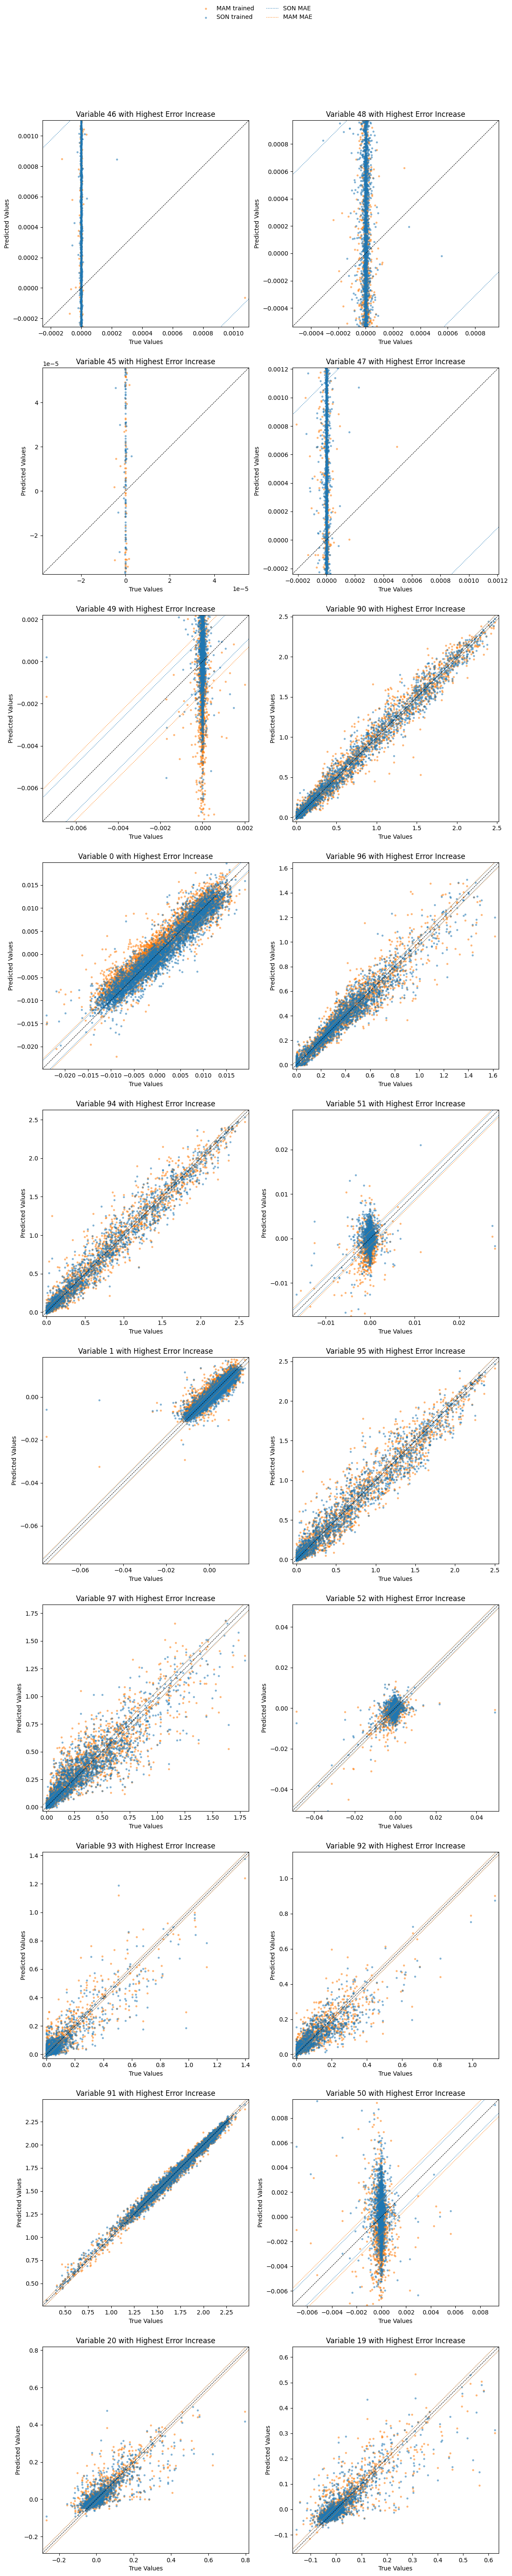

In [11]:
top_lot_to_show = 20
nrows = top_lot_to_show // 2
fig, axes = plt.subplots(nrows, 2, figsize=(12, 6 * nrows))  # smaller overall figure
axes = axes.ravel()

# Subsample size (adjust; 2000-5000 is usually responsive)
max_points = 4000

for i in range(top_lot_to_show):
    var_idx = int(sorted_error_differences_indeces[i])  # ensure plain int

    # select column for this variable
    son_preds = son_trained_son_preds[:, var_idx]
    son_targs = son_trained_son_targs[:, var_idx]
    son_mae = np.abs(son_preds - son_targs).mean()
    mam_preds = mam_trained_son_preds[:, var_idx]
    mam_targs = mam_trained_son_targs[:, var_idx]
    mam_mae = np.abs(mam_preds - mam_targs).mean()

    # subsample indices (same sample for both models to make comparison fair)
    n = len(son_preds)
    if n > max_points:
        rnd = np.random.default_rng(seed=42).choice(n, size=max_points, replace=False)
        son_x, son_y = son_targs[rnd], son_preds[rnd]
        mam_x, mam_y = mam_targs[rnd], mam_preds[rnd]
    else:
        son_x, son_y = son_targs, son_preds
        mam_x, mam_y = mam_targs, mam_preds

    ax = axes[i]
    # rasterized=True helps with vector outputs (PDF/SVG) and can speed rendering
    ax.scatter(mam_x, mam_y, alpha=0.45, s=6, label='MAM trained', rasterized=True, color='tab:orange')
    ax.scatter(son_x, son_y, alpha=0.45, s=6, label='SON trained', rasterized=True, color='tab:blue')

    vmin = min(son_x.min(), mam_x.min())
    vmax = max(son_x.max(), mam_x.max())
    pad = 0.02 * (vmax - vmin) if (vmax > vmin) else 0.1
    lo, hi = vmin - pad, vmax + pad
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)


    # MAE diagonals (SON)
    ax.plot([lo, hi], [lo + son_mae, hi + son_mae],
            color='tab:blue', ls=':', lw=1, label='SON MAE')
    ax.plot([lo, hi], [lo - son_mae, hi - son_mae],
            color='tab:blue', ls=':', lw=1)

    # MAE diagonals (MAM)
    ax.plot([lo, hi], [lo + mam_mae, hi + mam_mae],
            color='tab:orange', ls=':', lw=1, label='MAM MAE')
    ax.plot([lo, hi], [lo - mam_mae, hi - mam_mae],
        color='tab:orange', ls=':', lw=1)


    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Variable {var_idx} with Highest Error Increase')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')

# Legend only once (faster)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

So I am kinda disregarding the top few, for high altitude data as it seems like pure noise and neither model are at all close to getting it right. But there are variables like 90 and 0, where actually the model is learning some relationship in the data but clearly these points are also error prone.

- Variable 90 is unclear, and I would like to try and work out why in a bit more detail.
- Variable 0, looks as if there is a slight bias especially as the values get more negative. 

So I think we start with these two and see where we end up.


Ok, i've just added the mean absolute error for each of the models as diagonals on the plots, and I mean very useful but kinda suprising results:
1. I can see why it has given this ordering - the first ones have a really noticable gap in the errors 
2. I am actually suprised at how small the differences is for 90 and 0, 90 you almost can't see and 0 is more substantial. 

This is making me ask the quesiton - lets say in an ideal world I can get 90's error to match, then what performance increase does that give me?


Ok the next question I want to understand is -> is this an ood scenario? So annoyingly in this case the data is normalised differently which means the same input values has different meanings. 

In [12]:
son_trained_mse = ((son_trained_son_preds - son_trained_son_targs) ** 2).mean()
mam_trained_mse = ((mam_trained_son_preds - mam_trained_son_targs) ** 2).mean()
print("SON trained model on SON test set average MSE: ", son_trained_mse)
print("MAM trained model on SON test set average MSE: ", mam_trained_mse)


for i in [45, 90, 0]:
    dummy_predictions = mam_trained_son_preds.copy()
    dummy_predictions[:, i] = son_trained_son_preds[:, i]
    dummy_mse = ((dummy_predictions - son_trained_son_targs) ** 2).mean()
    print(f"Dummy model (MAM but Var {i} from SON) on SON test set average MSE: ", dummy_mse) 

SON trained model on SON test set average MSE:  0.0041275593
MAM trained model on SON test set average MSE:  0.0043644034
Dummy model (MAM but Var 45 from SON) on SON test set average MSE:  0.0043643885
Dummy model (MAM but Var 90 from SON) on SON test set average MSE:  0.0043441956
Dummy model (MAM but Var 0 from SON) on SON test set average MSE:  0.0043643815


Ok, so basically if I'm going for the more showy option then yeah I was correct in thinking it does have the biggest effect. But realistically, anything that ends up working will not do as great as that on 90 but also hopefully positively effect others as well so the values will all be very different!

But we are back to the question of how do we handle this.

On further look at 90, I feel that there is a lot of orange outliers - considerably more than blue. Now the true value itself is not ood - but perhaps the inputs are? Lets try and understand why these outliers are happening. And we can start by comparing the models train set with this set!

In [13]:
# Lets first load the training set
cfg.dataset.group_by_months.target_group = "MAM"
mam_trainset = data_preparation.ClimSimNpyDataset(
    cfg.dataset,
    cfg.testing.dataset_testing_type,
    "train",
    normalisation_stats=None,
    model=None,
    seed=0,
)

mam_trainset_input = mam_trainset.input.numpy()


2026-01-05 13:49:40,240 - INFO - Building dataset for group: MAM
2026-01-05 13:49:40,240 - INFO - Using sample rate directory: sample_rate_7
2026-01-05 13:49:46,069 - INFO - Loaded input shape: (2907264, 94)
2026-01-05 13:49:46,069 - INFO - Loaded target shape: (2907264, 98)
2026-01-05 13:49:46,120 - INFO - Using: train with 2325811 samples
2026-01-05 13:49:47,244 - INFO - Calculating normalization statistics from data.
2026-01-05 13:49:59,054 - INFO - Data is in MLP format; no conversion needed.


In [14]:

def calculate_centrality_and_equality(trainset_input: np.ndarray, testset_input: np.ndarray):
    # Lets start with my 'explainability' idea
    nmam_trainset, nvar_input = trainset_input.shape

    tol = 1e-8 # tolerance for float equality, adjust if needed

    # Pre-alloc output arrays
    percentage_within_array = np.empty((nson, nvar_input), dtype=float)
    percentage_equal_array = np.empty((nson, nvar_input), dtype=int)

    inv_nmam = 1.0 / nmam_trainset  # small micro-optimisation

    for j in range(nvar_input):
        col = trainset_input[:, j]
        sorted_col = np.sort(col)             # O(nmam log nmam) per column
        sample_vals = testset_input[:, j]  # shape (nson,)

        # counts of strictly less: index of first >= v  => number of elements < v
        left_idx = np.searchsorted(sorted_col, sample_vals, side='left')   # shape (nson,)
        # counts of strictly greater: nmam - index of last <= v => nmam - right_idx
        right_idx = np.searchsorted(sorted_col, sample_vals, side='right') # shape (nson,)
        number_less = left_idx
        number_greater = nmam_trainset - right_idx

        # counts of "equal" within tolerance: count of values in [v-tol, v+tol]
        left_eq = np.searchsorted(sorted_col, sample_vals - tol, side='left')
        right_eq = np.searchsorted(sorted_col, sample_vals + tol, side='right')
        number_equal = (right_eq - left_eq).astype(int)

        # Print only where number_equal > 0 (vectorized find, then loop over those indices)
        eq_idxs = np.nonzero(number_equal > 0)[0]
        # for i in eq_idxs:
        #     val = sample_vals[i]
        #     print(f"JJA sample {i}, feature {j}, value {val:.6g} -> "
        #           f"{number_less[i]} less, {number_greater[i]} greater, "
        #           f"{number_equal[i]} equal in MAM (tol={tol}).")

        # percentage_within_array[:, j] = (number_less * inv_nmam) * (number_greater * inv_nmam)
        percentage_within_array[:, j] = abs((number_less * inv_nmam) - 0.5) 
        percentage_equal_array[:, j] = number_equal
    return percentage_within_array, percentage_equal_array

mam_trained_percentage_within_array, mam_trained_percentage_equal_array = calculate_centrality_and_equality(mam_trainset_input, mam_trained_son_input)

In [15]:
print(mam_trained_percentage_within_array.shape)
print(mam_trained_percentage_equal_array.shape)

(287540, 94)
(287540, 94)


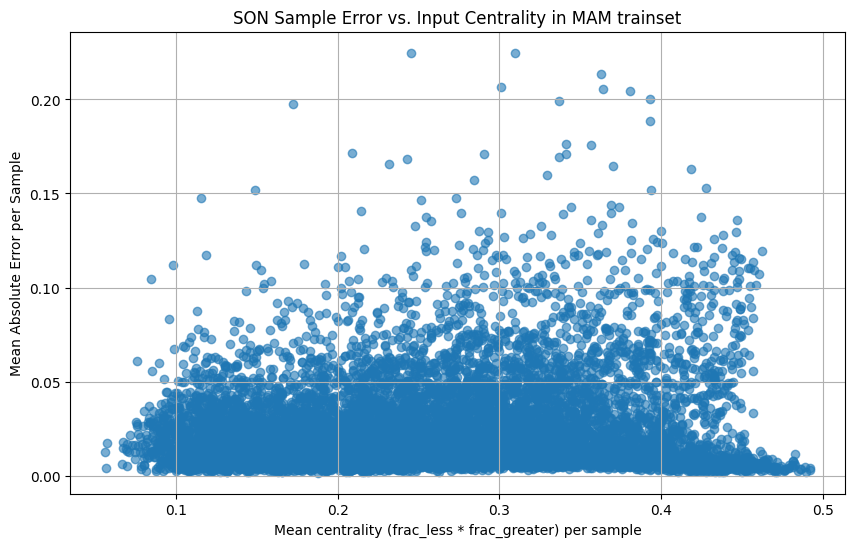

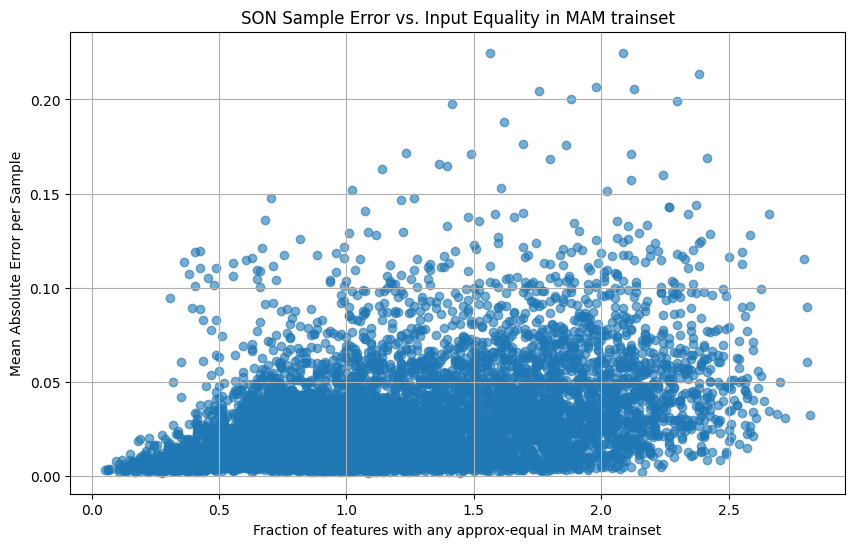

In [16]:
sample_size = 10000
rnd = np.random.default_rng(seed=42).choice(n, size=sample_size, replace=False)
mam_trained_mae = mam_trained_abs_error.mean(axis=1)

# Plot: Error vs centrality (product-of-fracs)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mam_trained_percentage_within_array.mean(axis=1)[rnd], mam_trained_mae[rnd], alpha=0.6)
ax.set_ylabel('Mean Absolute Error per Sample')
ax.set_xlabel('Mean centrality (frac_less * frac_greater) per sample')
ax.set_title('SON Sample Error vs. Input Centrality in MAM trainset')
ax.grid(True)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mam_trained_percentage_equal_array.mean(axis=1)[rnd], mam_trained_mae[rnd], alpha=0.6)
ax.set_ylabel('Mean Absolute Error per Sample')
ax.set_xlabel('Fraction of features with any approx-equal in MAM trainset')
ax.set_title('SON Sample Error vs. Input Equality in MAM trainset')
ax.grid(True)
plt.show()



Oooh ok, this is interesting.

So there is slight correlations but nothing very concrete. The first plot bascally says that the majoriy of errors are below 0.05 and these lower errors seem to be slightly more concentrated in the 'middle of the distributions' But saying that - there is a fair amount within the higher errors that are also spread across the x axis - so I am not sure much can be made of this. Then there is the weird behaviour seen in both plots where 'unsuported' values (x near to 0) only seem to have very low errors ...?

For the bottom plot the error seems to increase the larger the fraction of features equal to the more error!

I think as a whole - this is a good starting point but there is way to much hidden information here to get any real readings so lets dive deeper 

In [17]:
mam_trained_percentage_within_array.shape

(287540, 94)

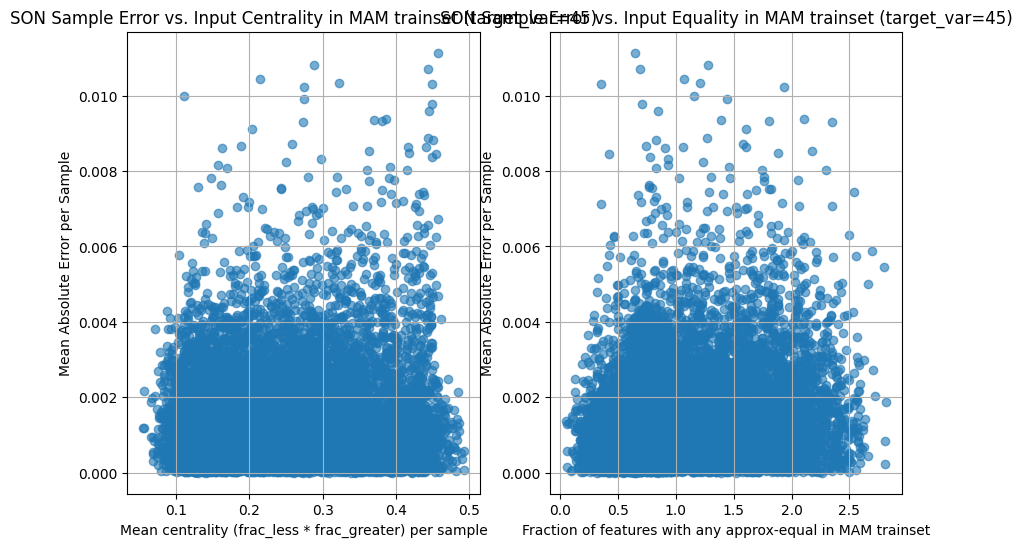

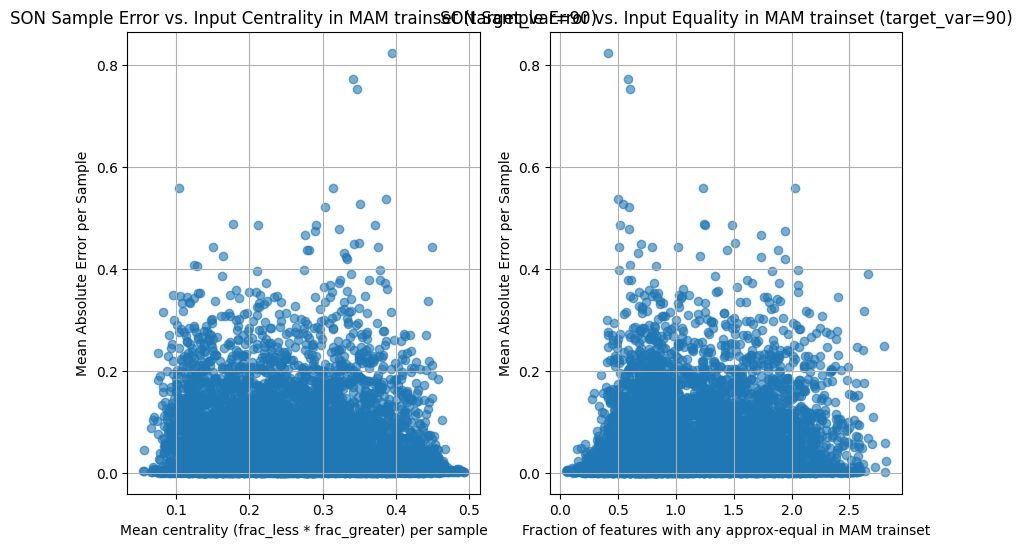

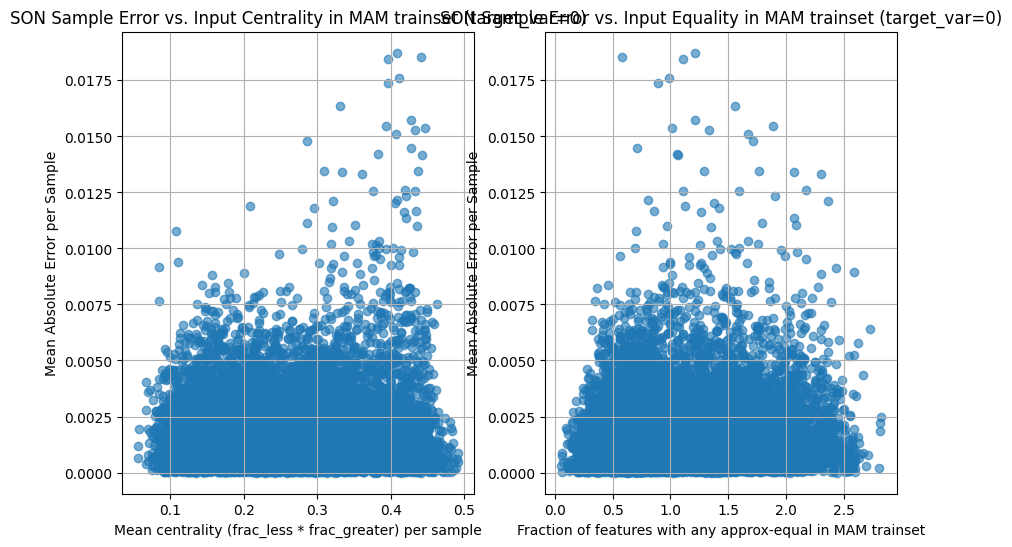

In [18]:
sample_size = 10000
target_var = 90
for i, target_var in enumerate([45, 90, 0]):
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    rnd = np.random.default_rng(seed=42).choice(n, size=sample_size, replace=False)
    mam_trained_mae = mam_trained_abs_error[:, target_var]

    # Plot: Error vs centrality (product-of-fracs)
    axes[0].scatter(mam_trained_percentage_within_array.mean(axis=1)[rnd], mam_trained_mae[rnd], alpha=0.6)
    axes[0].set_ylabel('Mean Absolute Error per Sample')
    axes[0].set_xlabel('Mean centrality (frac_less * frac_greater) per sample')
    axes[0].set_title(f'SON Sample Error vs. Input Centrality in MAM trainset (target_var={target_var})')
    axes[0].grid(True)


    axes[1].scatter(mam_trained_percentage_equal_array.mean(axis=1)[rnd], mam_trained_mae[rnd], alpha=0.6)
    axes[1].set_ylabel('Mean Absolute Error per Sample')
    axes[1].set_xlabel('Fraction of features with any approx-equal in MAM trainset')
    axes[1].set_title(f'SON Sample Error vs. Input Equality in MAM trainset (target_var={target_var})')
    axes[1].grid(True)
    plt.show()

Sorry bad plots but the data is there and the idea is clearish, I have chosen these three variables that have been of interest to us. But when we look at all the input variables there is still way to much information!

Lets plot the top 4 and bottom 4 regarding centrality for our variables and see how it looks 

[0.30586775 0.3159958  0.35090213 0.36961393]
[0.18253609 0.19026427 0.20714248 0.22063818]


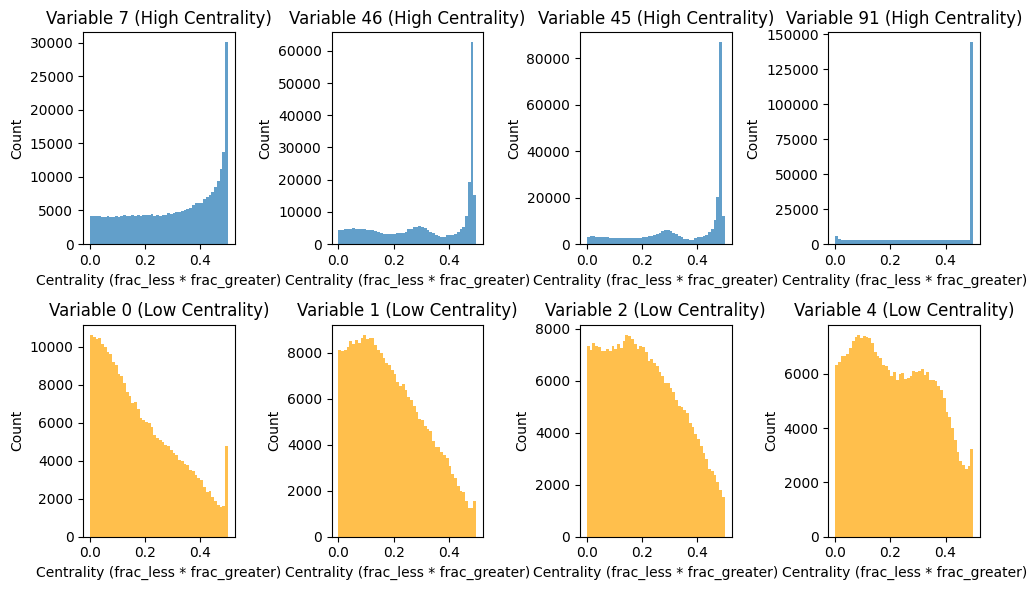

In [19]:

argsorted_centrality = np.argsort(mam_trained_percentage_within_array.mean(axis=0))
vars_of_interest = 4
top_vars = argsorted_centrality[-4:]
bottom_vars = argsorted_centrality[:4]

print(mam_trained_percentage_within_array.mean(axis=0)[top_vars])
print(mam_trained_percentage_within_array.mean(axis=0)[bottom_vars])

fig, axes = plt.subplots(2, vars_of_interest, figsize=(10, 6))

for i in range(vars_of_interest):
    var_idx = top_vars[i]
    axes[0, i].hist(mam_trained_percentage_within_array[:, var_idx], bins=50, alpha=0.7)
    axes[0, i].set_title(f'Variable {var_idx} (High Centrality)')
    axes[0, i].set_xlabel('Centrality (frac_less * frac_greater)')
    axes[0, i].set_ylabel('Count')

    var_idx = bottom_vars[i]
    axes[1, i].hist(mam_trained_percentage_within_array[:, var_idx], bins=50, alpha=0.7, color='orange')
    axes[1, i].set_title(f'Variable {var_idx} (Low Centrality)')
    axes[1, i].set_xlabel('Centrality (frac_less * frac_greater)')
    axes[1, i].set_ylabel('Count')
plt.tight_layout()
plt.show()

[0.30586775 0.3159958  0.35090213 0.36961393]
[0.18253609 0.19026427 0.20714248 0.22063818]


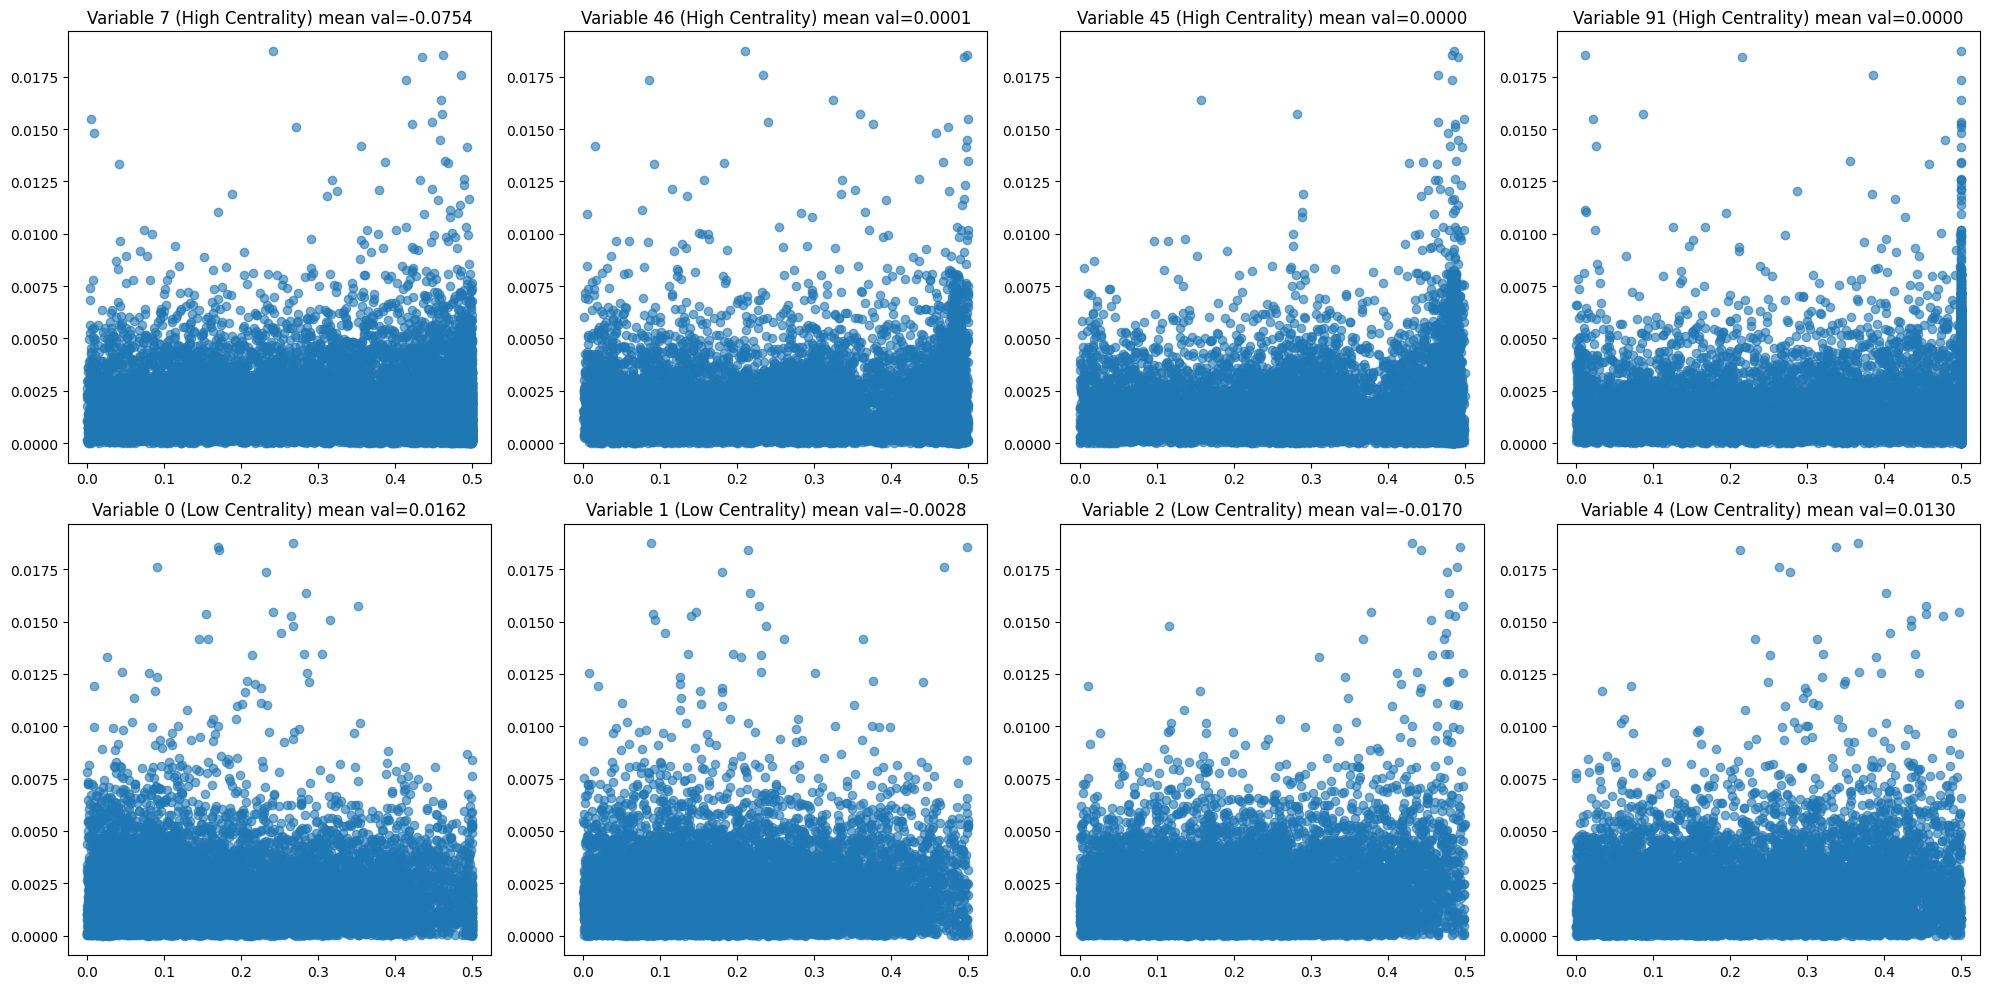

In [20]:
argsorted_centrality = np.argsort(mam_trained_percentage_within_array.mean(axis=0))
vars_of_interest = 4
top_vars = argsorted_centrality[-4:]
bottom_vars = argsorted_centrality[:4]

print(mam_trained_percentage_within_array.mean(axis=0)[top_vars])
print(mam_trained_percentage_within_array.mean(axis=0)[bottom_vars])

output_target_var = 0
mam_trained_mae = mam_trained_abs_error[:, output_target_var]

fig, axes = plt.subplots(2, vars_of_interest, figsize=(20, 10))

for i in range(vars_of_interest):
    var_idx = top_vars[i]
    top_percentage_within = mam_trained_percentage_within_array[:, var_idx][rnd]
    axes[0, i].scatter(top_percentage_within, mam_trained_mae[rnd], alpha=0.6)
    axes[0, i].set_title(f'Variable {var_idx} (High Centrality) mean val={mam_trainset_input[:, var_idx].mean():.4f}')


    var_idx = bottom_vars[i]
    bottom_percentage_within = mam_trained_percentage_within_array[:, var_idx][rnd]
    axes[1, i].scatter(bottom_percentage_within, mam_trained_mae[rnd], alpha=0.6)
    axes[1, i].set_title(f'Variable {var_idx} (Low Centrality) mean val={mam_trainset_input[:, var_idx].mean():.4f}')

plt.tight_layout()
plt.show()

[ 2.63308061  2.85880573  2.96137929 19.71497183]
[0.11684635 0.1185609  0.11875565 0.11889128]


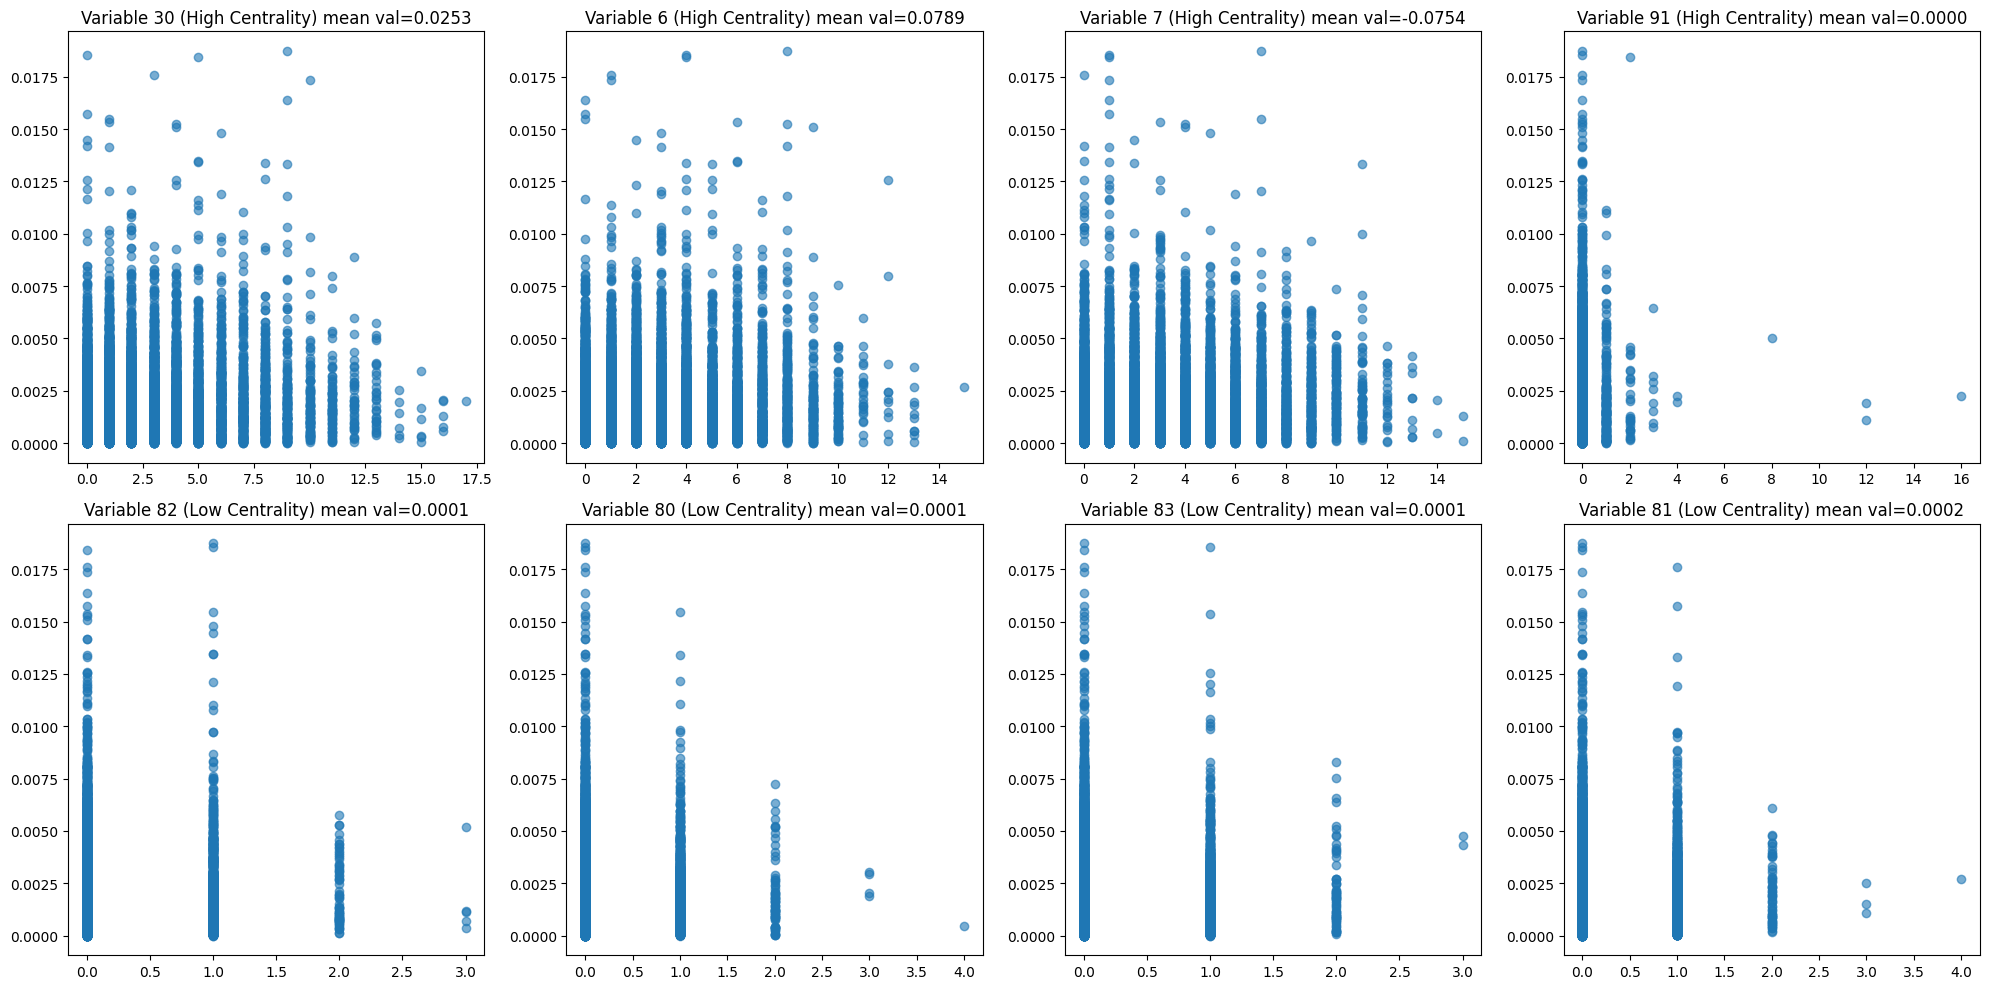

In [21]:
argsorted_equality = np.argsort(mam_trained_percentage_equal_array.mean(axis=0))
vars_of_interest = 4
top_vars = argsorted_equality[-4:]
bottom_vars = argsorted_equality[:4]

print(mam_trained_percentage_equal_array.mean(axis=0)[top_vars])
print(mam_trained_percentage_equal_array.mean(axis=0)[bottom_vars])

output_target_var = 0
mam_trained_mae = mam_trained_abs_error[:, output_target_var]

fig, axes = plt.subplots(2, vars_of_interest, figsize=(20, 10))

for i in range(vars_of_interest):
    var_idx = top_vars[i]
    top_percentage_within = mam_trained_percentage_equal_array[:, var_idx][rnd]
    axes[0, i].scatter(top_percentage_within, mam_trained_mae[rnd], alpha=0.6)
    axes[0, i].set_title(f'Variable {var_idx} (High Centrality) mean val={mam_trainset_input[:, var_idx].mean():.4f}')


    var_idx = bottom_vars[i]
    bottom_percentage_within = mam_trained_percentage_equal_array[:, var_idx][rnd]
    axes[1, i].scatter(bottom_percentage_within, mam_trained_mae[rnd], alpha=0.6)
    axes[1, i].set_title(f'Variable {var_idx} (Low Centrality) mean val={mam_trainset_input[:, var_idx].mean():.4f}')

plt.tight_layout()
plt.show()

(287540, 94)


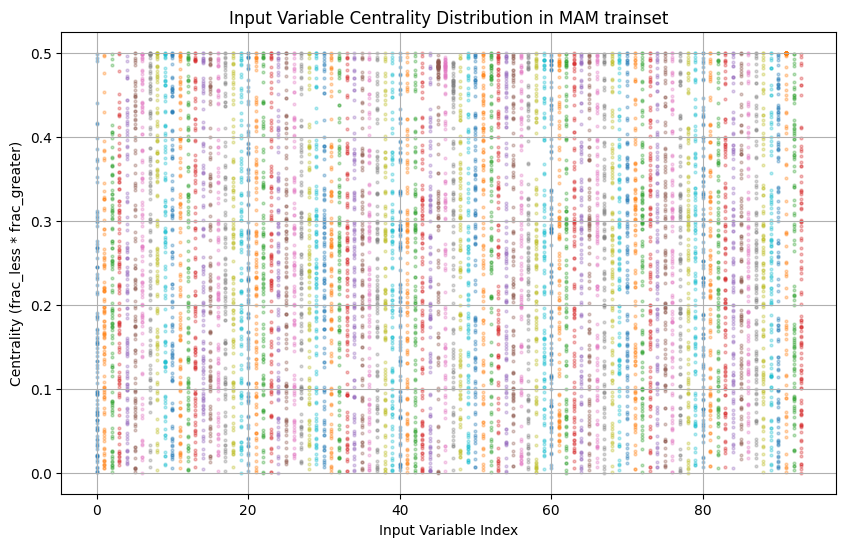

In [22]:
print(mam_trained_percentage_within_array.shape)
sample_size = 100

fig, ax = plt.subplots(figsize=(10, 6))
rnd = np.random.default_rng(seed=42).choice(n, size=sample_size, replace=False)
sampled_centrality = mam_trained_percentage_within_array[rnd]

for var in range(sampled_centrality.shape[1]):
    x = np.ones_like(sampled_centrality[:, var]) * var
    ax.scatter(x, sampled_centrality[:, var], alpha=0.3, s=4)
ax.set_ylabel('Centrality (frac_less * frac_greater)')
ax.set_xlabel('Input Variable Index')
ax.set_title('Input Variable Centrality Distribution in MAM trainset')
ax.grid(True)
plt.show()

(287540, 94)


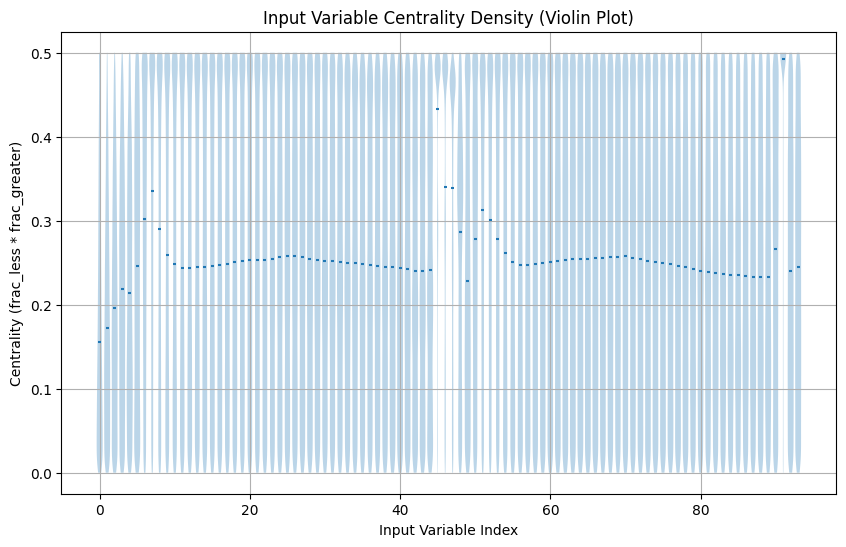

In [23]:
import numpy as np
import matplotlib.pyplot as plt

print(mam_trained_percentage_within_array.shape)

sample_size = 100000
rnd = np.random.default_rng(seed=42).choice(
    mam_trained_percentage_within_array.shape[0],
    size=sample_size,
    replace=False
)
sampled_centrality = mam_trained_percentage_within_array[rnd]

fig, ax = plt.subplots(figsize=(10, 6))

parts = ax.violinplot(
    [sampled_centrality[:, var] for var in range(sampled_centrality.shape[1])],
    positions=np.arange(sampled_centrality.shape[1]),
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

ax.set_ylabel('Centrality (frac_less * frac_greater)')
ax.set_xlabel('Input Variable Index')
ax.set_title('Input Variable Centrality Density (Violin Plot)')
ax.grid(True)

plt.show()


Lets try and look at how different 'sections for each variable correspond to different errors.

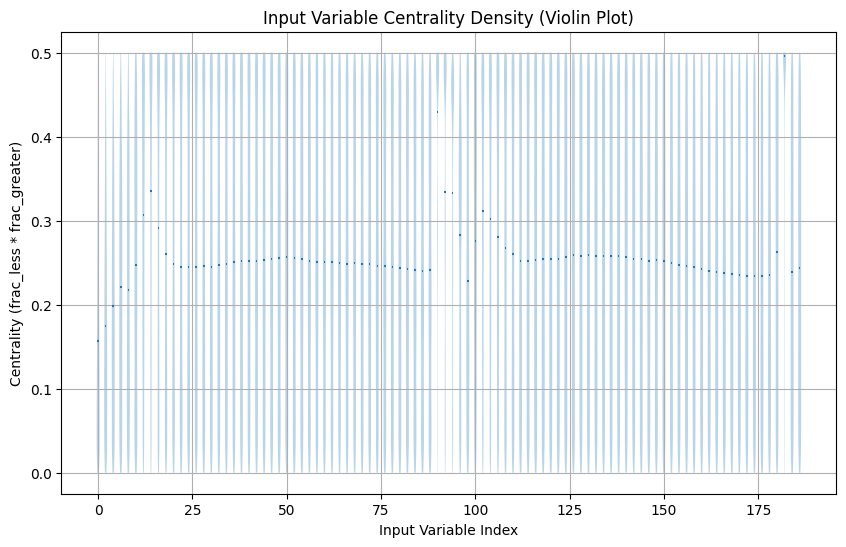

In [24]:
mam_trained_abs_error.shape

error = mam_trained_abs_error.mean(axis=1)
ranges = [[0, 0.05], [0.05, 0.1], [0.1, 0.15], [0.15, 0.2], [0.2, 0.25]]

    


sample_size = 10000
rnd = np.random.default_rng(seed=42).choice(
    mam_trained_percentage_within_array.shape[0],
    size=sample_size,
    replace=False
)
sampled_centrality = mam_trained_percentage_within_array[rnd]
nvar_input = sampled_centrality.shape[1]
fig, ax = plt.subplots(figsize=(10, 6))

parts = ax.violinplot(
    [sampled_centrality[:, var] for var in range(nvar_input)],
    positions=np.arange(nvar_input)*2,
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

for var in range(nvar_input):
    var_centrality = mam_trained_percentage_within_array[:, var]
    for r in ranges:
        idxs = np.where((var_centrality >= r[0]) & (var_centrality < r[1]))[0]
        specific_errors = error[idxs]
        specific_error_mean = specific_errors.mean() 
    
        # plot at point (var*2 + offset, range) the specific error mean
        # TODO
    

ax.set_ylabel('Centrality (frac_less * frac_greater)')
ax.set_xlabel('Input Variable Index')
ax.set_title('Input Variable Centrality Density (Violin Plot)')
ax.grid(True)

plt.show()



In [36]:

def plot_centrality_with_error(abs_error: np.ndarray, percentage_within_array: np.ndarray, ranges: list=None, target_var: int=None):
    if target_var is None:
        error = abs_error.mean(axis=1)
    else:
        error = abs_error[:, target_var]
    # ranges = [[0, 0.05], [0.05, 0.1], [0.1, 0.15], [0.15, 0.2], [0.2, 0.25]]
    if ranges == None:
        ranges = [[0, 0.1], [0.1, 0.2], [0.2, 0.3], [0.3, 0.4], [0.4, 0.5]]

    sample_size = 10000
    rnd = np.random.default_rng(seed=42).choice(
        percentage_within_array.shape[0],
        size=sample_size,
        replace=False
    )
    sampled_centrality = percentage_within_array[rnd]
    nvar_input = sampled_centrality.shape[1]

    # Precompute mean errors for every (var, range) so we can set color normalization
    mean_errors = np.full((nvar_input, len(ranges)), np.nan)

    for var in range(nvar_input):
        var_errors = []
        var_centrality = percentage_within_array[:, var]
        for i, r in enumerate(ranges):
            idxs = np.where((var_centrality >= r[0]) & (var_centrality < r[1]))[0]
            if idxs.size == 0:
                continue
            mean_errors[var, i] = error[idxs].mean()
            var_errors.append(mean_errors[var, i])
        print(np.mean(np.array(var_errors)))
    # Determine colormap normalization from existing values
    valid_vals = mean_errors[~np.isnan(mean_errors)]
    if valid_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = valid_vals.min(), valid_vals.max()

    cmap_name = "viridis"   # change if you'd like a different colormap
    cmap = get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(30, 15))

    # Draw colored rectangles first (so violins overlay them)
    positions = np.arange(nvar_input) * 2
    rect_width = 0.8
    half_w = rect_width / 2.0
    alpha_rect = 0.7

    for var in range(nvar_input):
        center_x = positions[var] + 1.0  # centered around var*2 + 1
        left_x = center_x - half_w
        for i, r in enumerate(ranges):
            mean_e = mean_errors[var, i]
            if np.isnan(mean_e):
                # no data in this interval -> skip (or draw a neutral color if you prefer)
                continue
            y0, y1 = r[0], r[1]
            color = cmap(norm(mean_e))
            rect = Rectangle(
                (left_x, y0),           # (x,y) lower-left
                rect_width,             # width
                (y1 - y0),              # height
                facecolor=color,
                edgecolor=None,
                alpha=alpha_rect,
                zorder=1
            )
            ax.add_patch(rect)

    # Now draw violins on top
    parts = ax.violinplot(
        [sampled_centrality[:, var] for var in range(nvar_input)],
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Optional: style violins (light edge and fill)
    # for pc in parts['bodies']:
    #     pc.set_alpha(0.9)
    #     pc.set_edgecolor('black')
    #     pc.set_linewidth(0.3)

    # Add colorbar (create a ScalarMappable just for the colorbar)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(valid_vals)  # any non-empty array is fine; used to scale colorbar
    cbar = fig.colorbar(sm, ax=ax, pad=0.03)
    cbar.set_label('Mean absolute error')

    # Cosmetics
    ax.set_ylabel('Centrality (frac_less * frac_greater)')
    ax.set_xlabel('Input Variable Index')
    ax.set_title('Input Variable Centrality Density (Violin Plot) with Mean Error per Range')
    ax.set_xticks(positions)
    ax.set_xticklabels([str(i) for i in range(nvar_input)])
    ax.grid(True)

    # widen x-limits to make room for rectangles/annotations
    ax.set_xlim(positions.min() - 1, positions.max() + 2)

    plt.tight_layout()
    plt.show()



Ok this is a big plot to digest. What this is showing the distribution of the centrality of a datapoint compared to its trainset combined with the mean error that different levels of centrality have. What we see is as expected - lower centrality results in high error. 
What is interesting is when we focus on specific variables, the error seems to come from a specific 'ood' variable ...

0.040571273863315584
0.04115082547068596
0.04165521562099457
0.041759006679058075
0.04182591512799263
0.04191450327634812
0.04241122230887413
0.04241417795419693
0.042311587184667585
0.042162641137838366
0.04207318276166916
0.042018556594848634
0.04201759621500969
0.04200698733329773
0.0419784277677536
0.04196889847517014
0.04197600781917572
0.041985072940587995
0.04199298322200775
0.041978562623262404
0.041987334936857225
0.04199141934514046
0.04199497550725937
0.04198846220970154
0.041978735476732254
0.04196466058492661
0.041961361467838285
0.04195362403988838
0.04193535372614861
0.04193293079733849
0.041941022127866746
0.041948655247688295
0.04196591824293137
0.04198215007781982
0.04199989810585976
0.04200849160552025
0.04200732484459877
0.0419935293495655
0.04197811037302017
0.04194825068116188
0.04190744087100029
0.041860203444957736
0.0418284647166729
0.041811151802539824
0.041816797107458115
0.04519162625074387
0.04436436742544174
0.04456810355186462
0.042561046034097674
0.04167

/tmp/ipykernel_1296098/1615257330.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


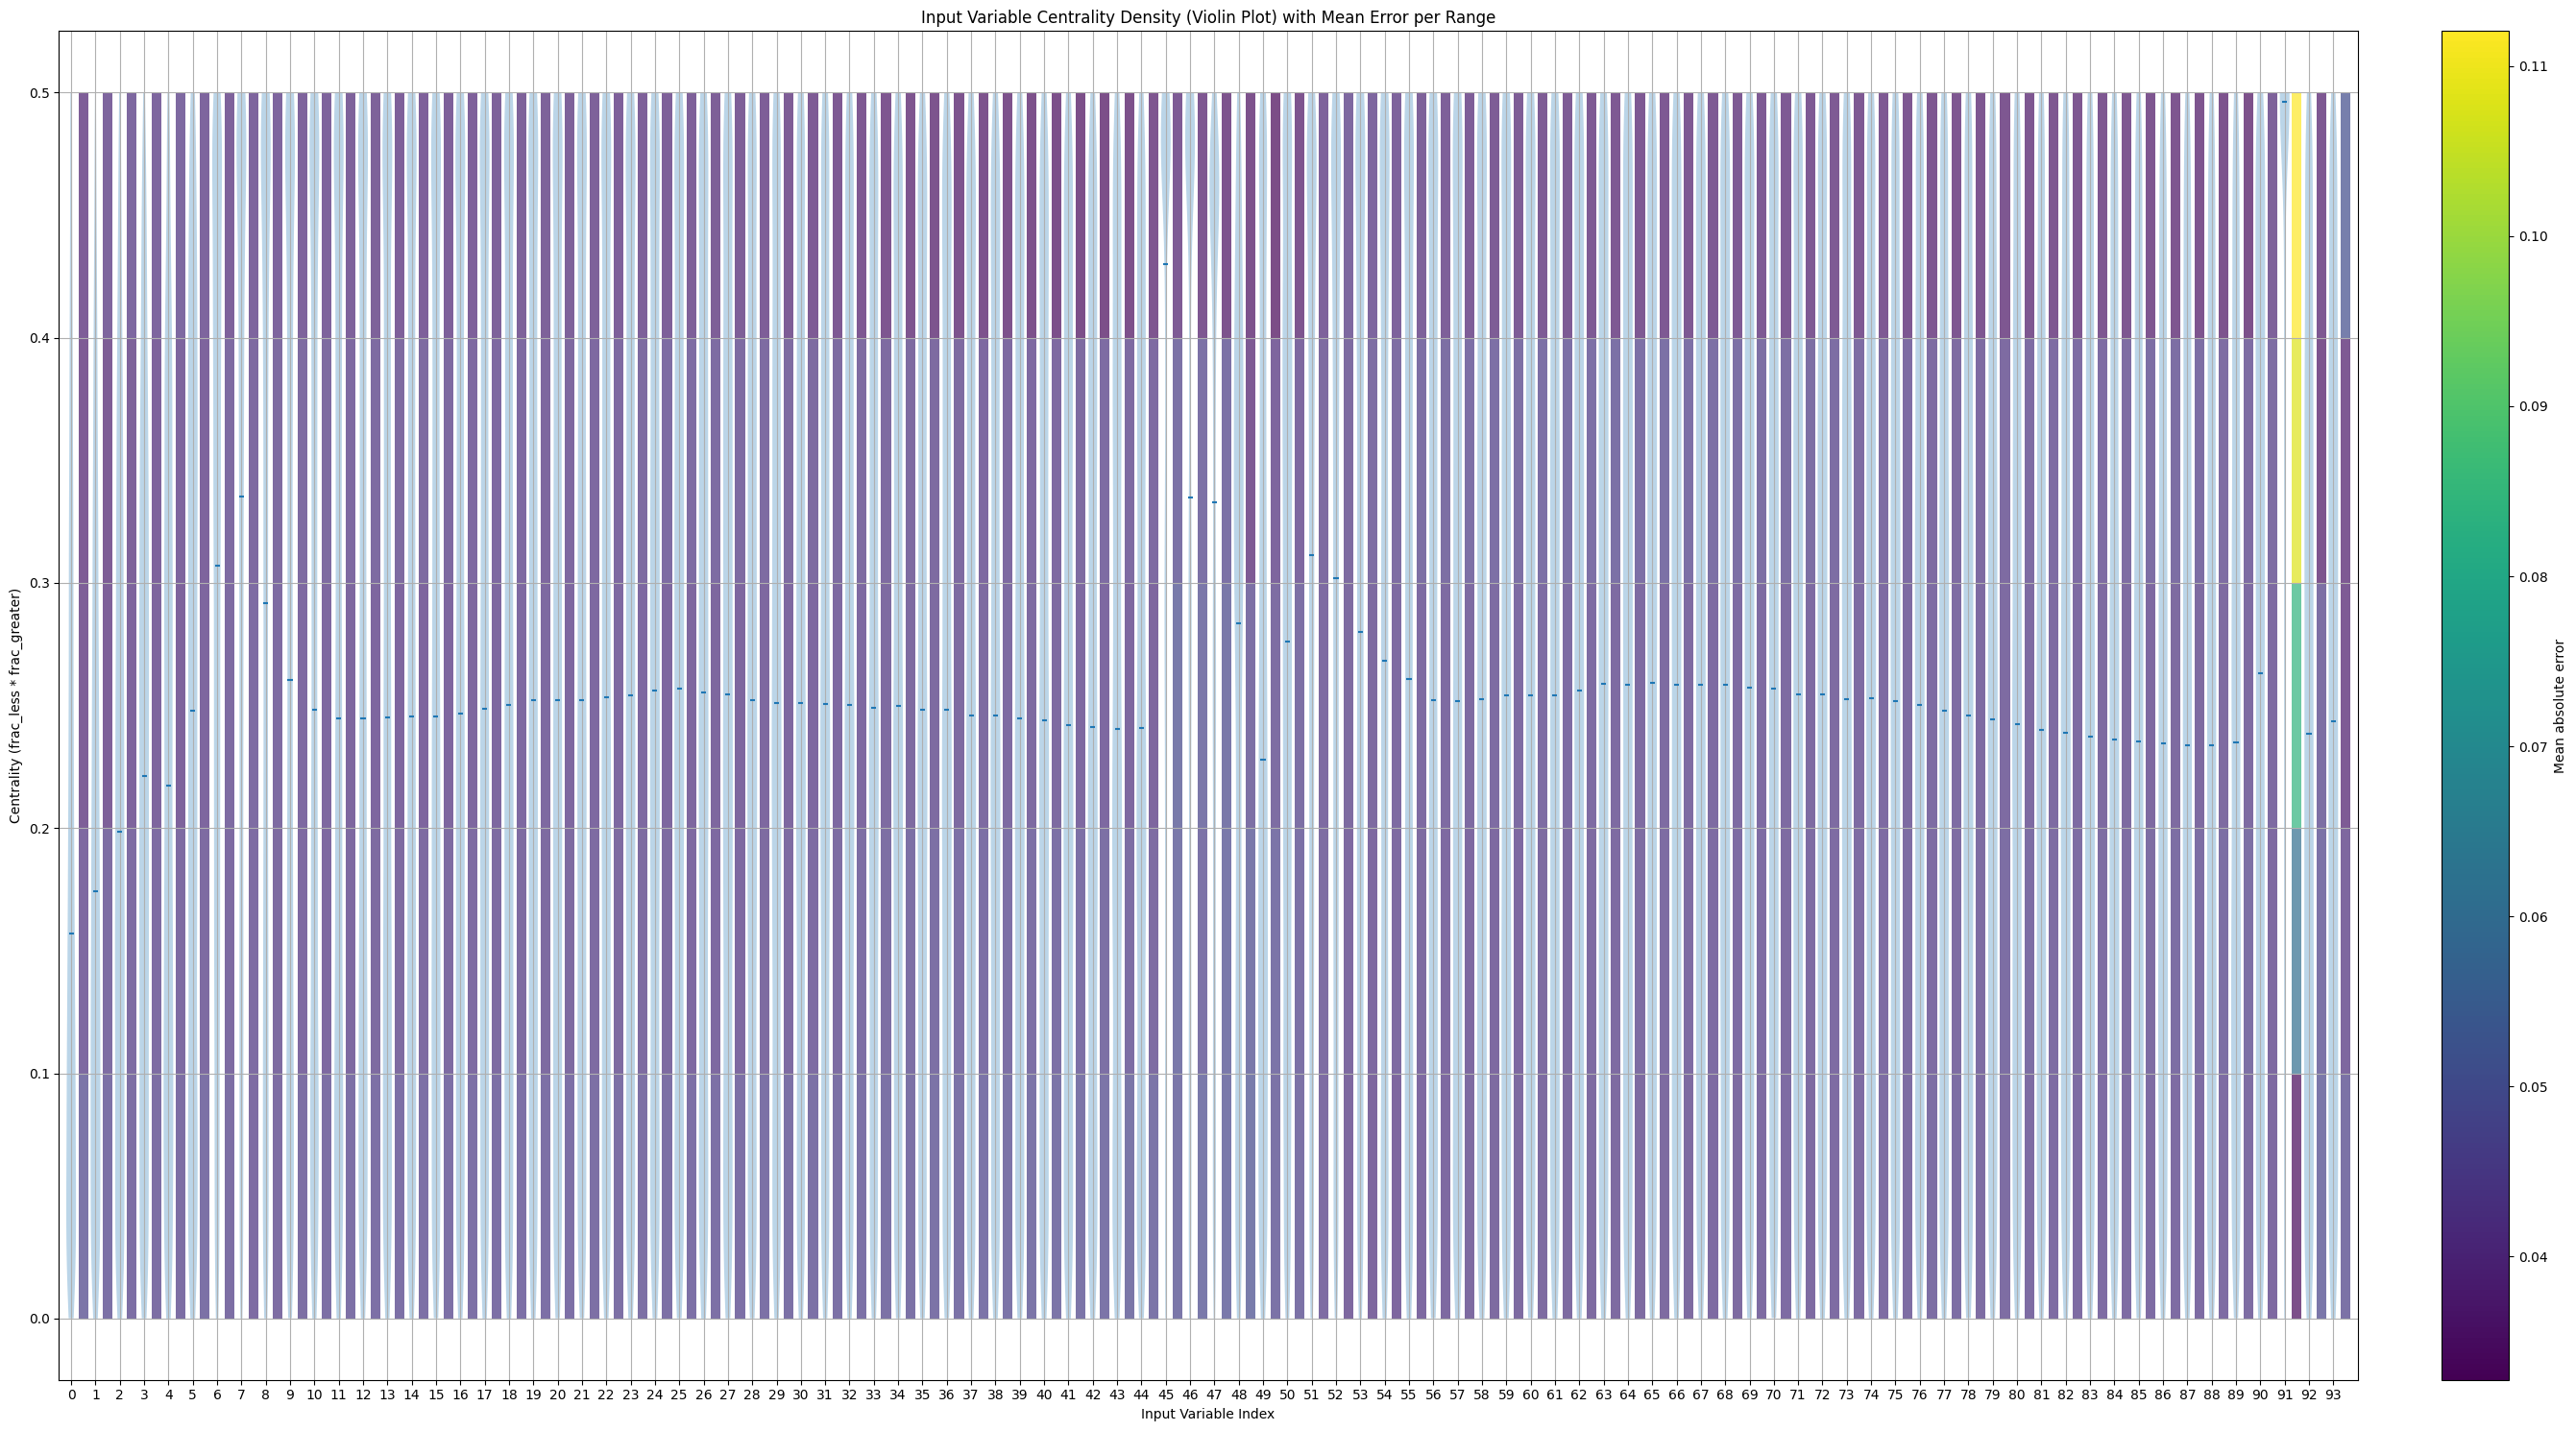

In [26]:
plot_centrality_with_error(mam_trained_abs_error, mam_trained_percentage_within_array, target_var=90)

0.04054543934762478
0.041376634314656255
0.0417662039399147
0.04179985374212265
0.04184187613427639
0.041894670203328134
0.04250516779720783
0.042476268485188484
0.0423712257295847
0.042277668789029124
0.04221275113523006
0.04217323958873749
0.04216853901743889
0.0421742107719183
0.04213431812822819
0.04211961328983307
0.042126207426190374
0.04212384670972824
0.04211603254079819
0.042096300050616264
0.04207112155854702
0.042086110636591914
0.04207744374871254
0.042056598141789435
0.04205184243619442
0.042038314417004584
0.04202466160058975
0.042031442001461986
0.04201030060648918
0.042009171470999716
0.042019474878907205
0.04202226996421814
0.04203506112098694
0.04204528257250786
0.042059556022286414
0.04207230694591999
0.04206863380968571
0.042051398754119874
0.042025537230074406
0.04199130889028311
0.04194141738116741
0.04187794346362352
0.04182578139007091
0.0417855653911829
0.04176194779574871
0.04527682326734066
0.04483935795724392
0.04479172416031361
0.04260093420743942
0.0417737

/tmp/ipykernel_1296098/3884260340.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


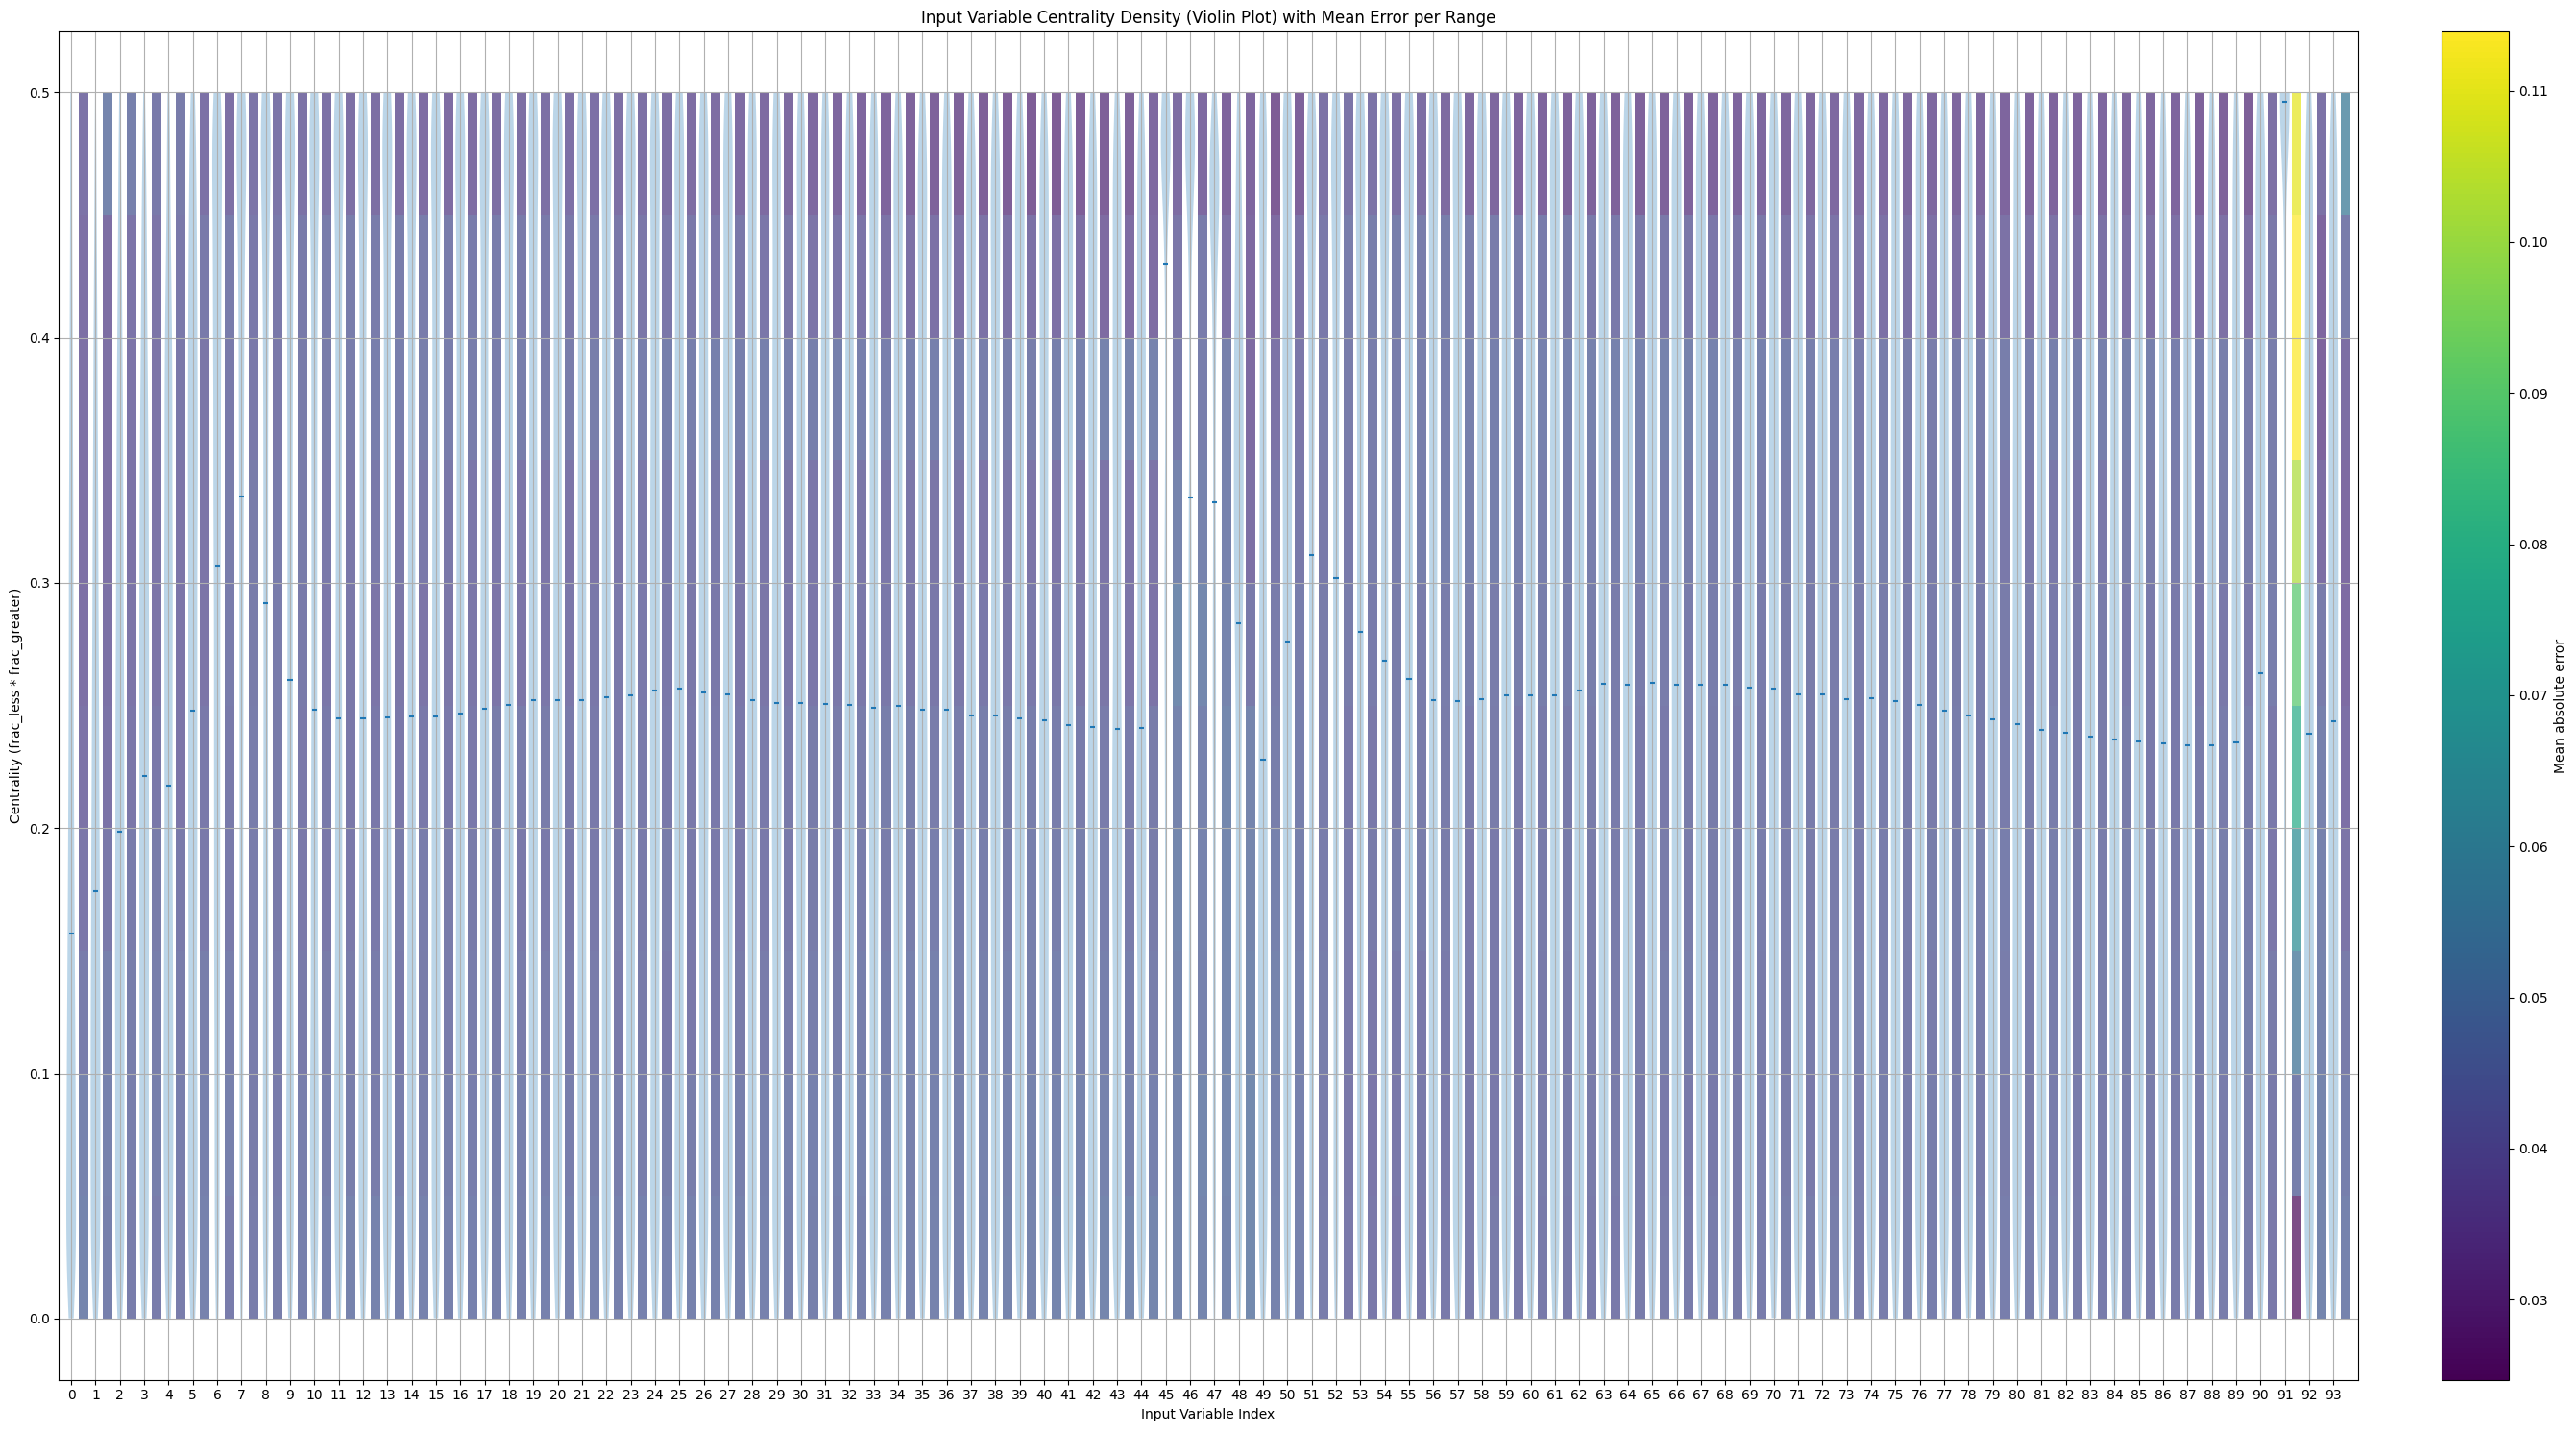

In [37]:
ranges = [[0, 0.05], [0.05, 0.1], [0.1, 0.15],  [0.15, 0.2], [0.2, 0.25], [0.25, 0.3], [0.3, 0.35], [0.35, 0.4], [0.4, 0.45], [0.45, 0.5]]

plot_centrality_with_error(mam_trained_abs_error, mam_trained_percentage_within_array, ranges=ranges, target_var=90)

Now lets see how this compares to son trained 

In [27]:
# Lets first load the training set
cfg.dataset.group_by_months.target_group = "SON"
son_trainset = data_preparation.ClimSimNpyDataset(
    cfg.dataset,
    cfg.testing.dataset_testing_type,
    "train",
    normalisation_stats=None,
    model=None,
    seed=0,
)

son_trainset_input = son_trainset.input.numpy()

2026-01-05 13:51:00,375 - INFO - Building dataset for group: SON
2026-01-05 13:51:00,376 - INFO - Using sample rate directory: sample_rate_7
2026-01-05 13:51:06,208 - INFO - Loaded input shape: (2875392, 94)
2026-01-05 13:51:06,208 - INFO - Loaded target shape: (2875392, 98)
2026-01-05 13:51:06,628 - INFO - Using: train with 2300313 samples
2026-01-05 13:51:33,085 - INFO - Calculating normalization statistics from data.
2026-01-05 13:52:12,263 - INFO - Data is in MLP format; no conversion needed.


In [28]:
son_trained_percentage_within_array, son_trained_percentage_equal_array = calculate_centrality_and_equality(son_trainset_input, son_trained_son_input)


0.035356313735246656
0.03535566776990891
0.035354864597320554
0.03535668775439262
0.035353418439626694
0.035353214293718335
0.035350827127695085
0.0353455513715744
0.03534200489521026
0.03534200862050056
0.035344739258289334
0.035350427776575086
0.03535183817148209
0.035353855788707735
0.035352463647723195
0.0353503130376339
0.0353473637253046
0.03534861095249653
0.035348879918456075
0.035350659117102626
0.03535012565553188
0.03535211682319641
0.03534918129444122
0.035349854826927186
0.03534985892474651
0.035346683114767075
0.03534973971545696
0.03535183183848858
0.035350262001156804
0.035349547117948535
0.0353493943810463
0.035350453853607175
0.03535033017396927
0.03535121902823448
0.03535201661288738
0.03535224013030529
0.03535258136689663
0.035353713855147365
0.03535558320581913
0.035358674451708795
0.03536136187613011
0.03536118157207966
0.035358714312314986
0.03535711020231247
0.035356393456459044
0.035358224809169767
0.035366231203079225
0.03536713495850563
0.035360456258058545
0

/tmp/ipykernel_1296098/1615257330.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


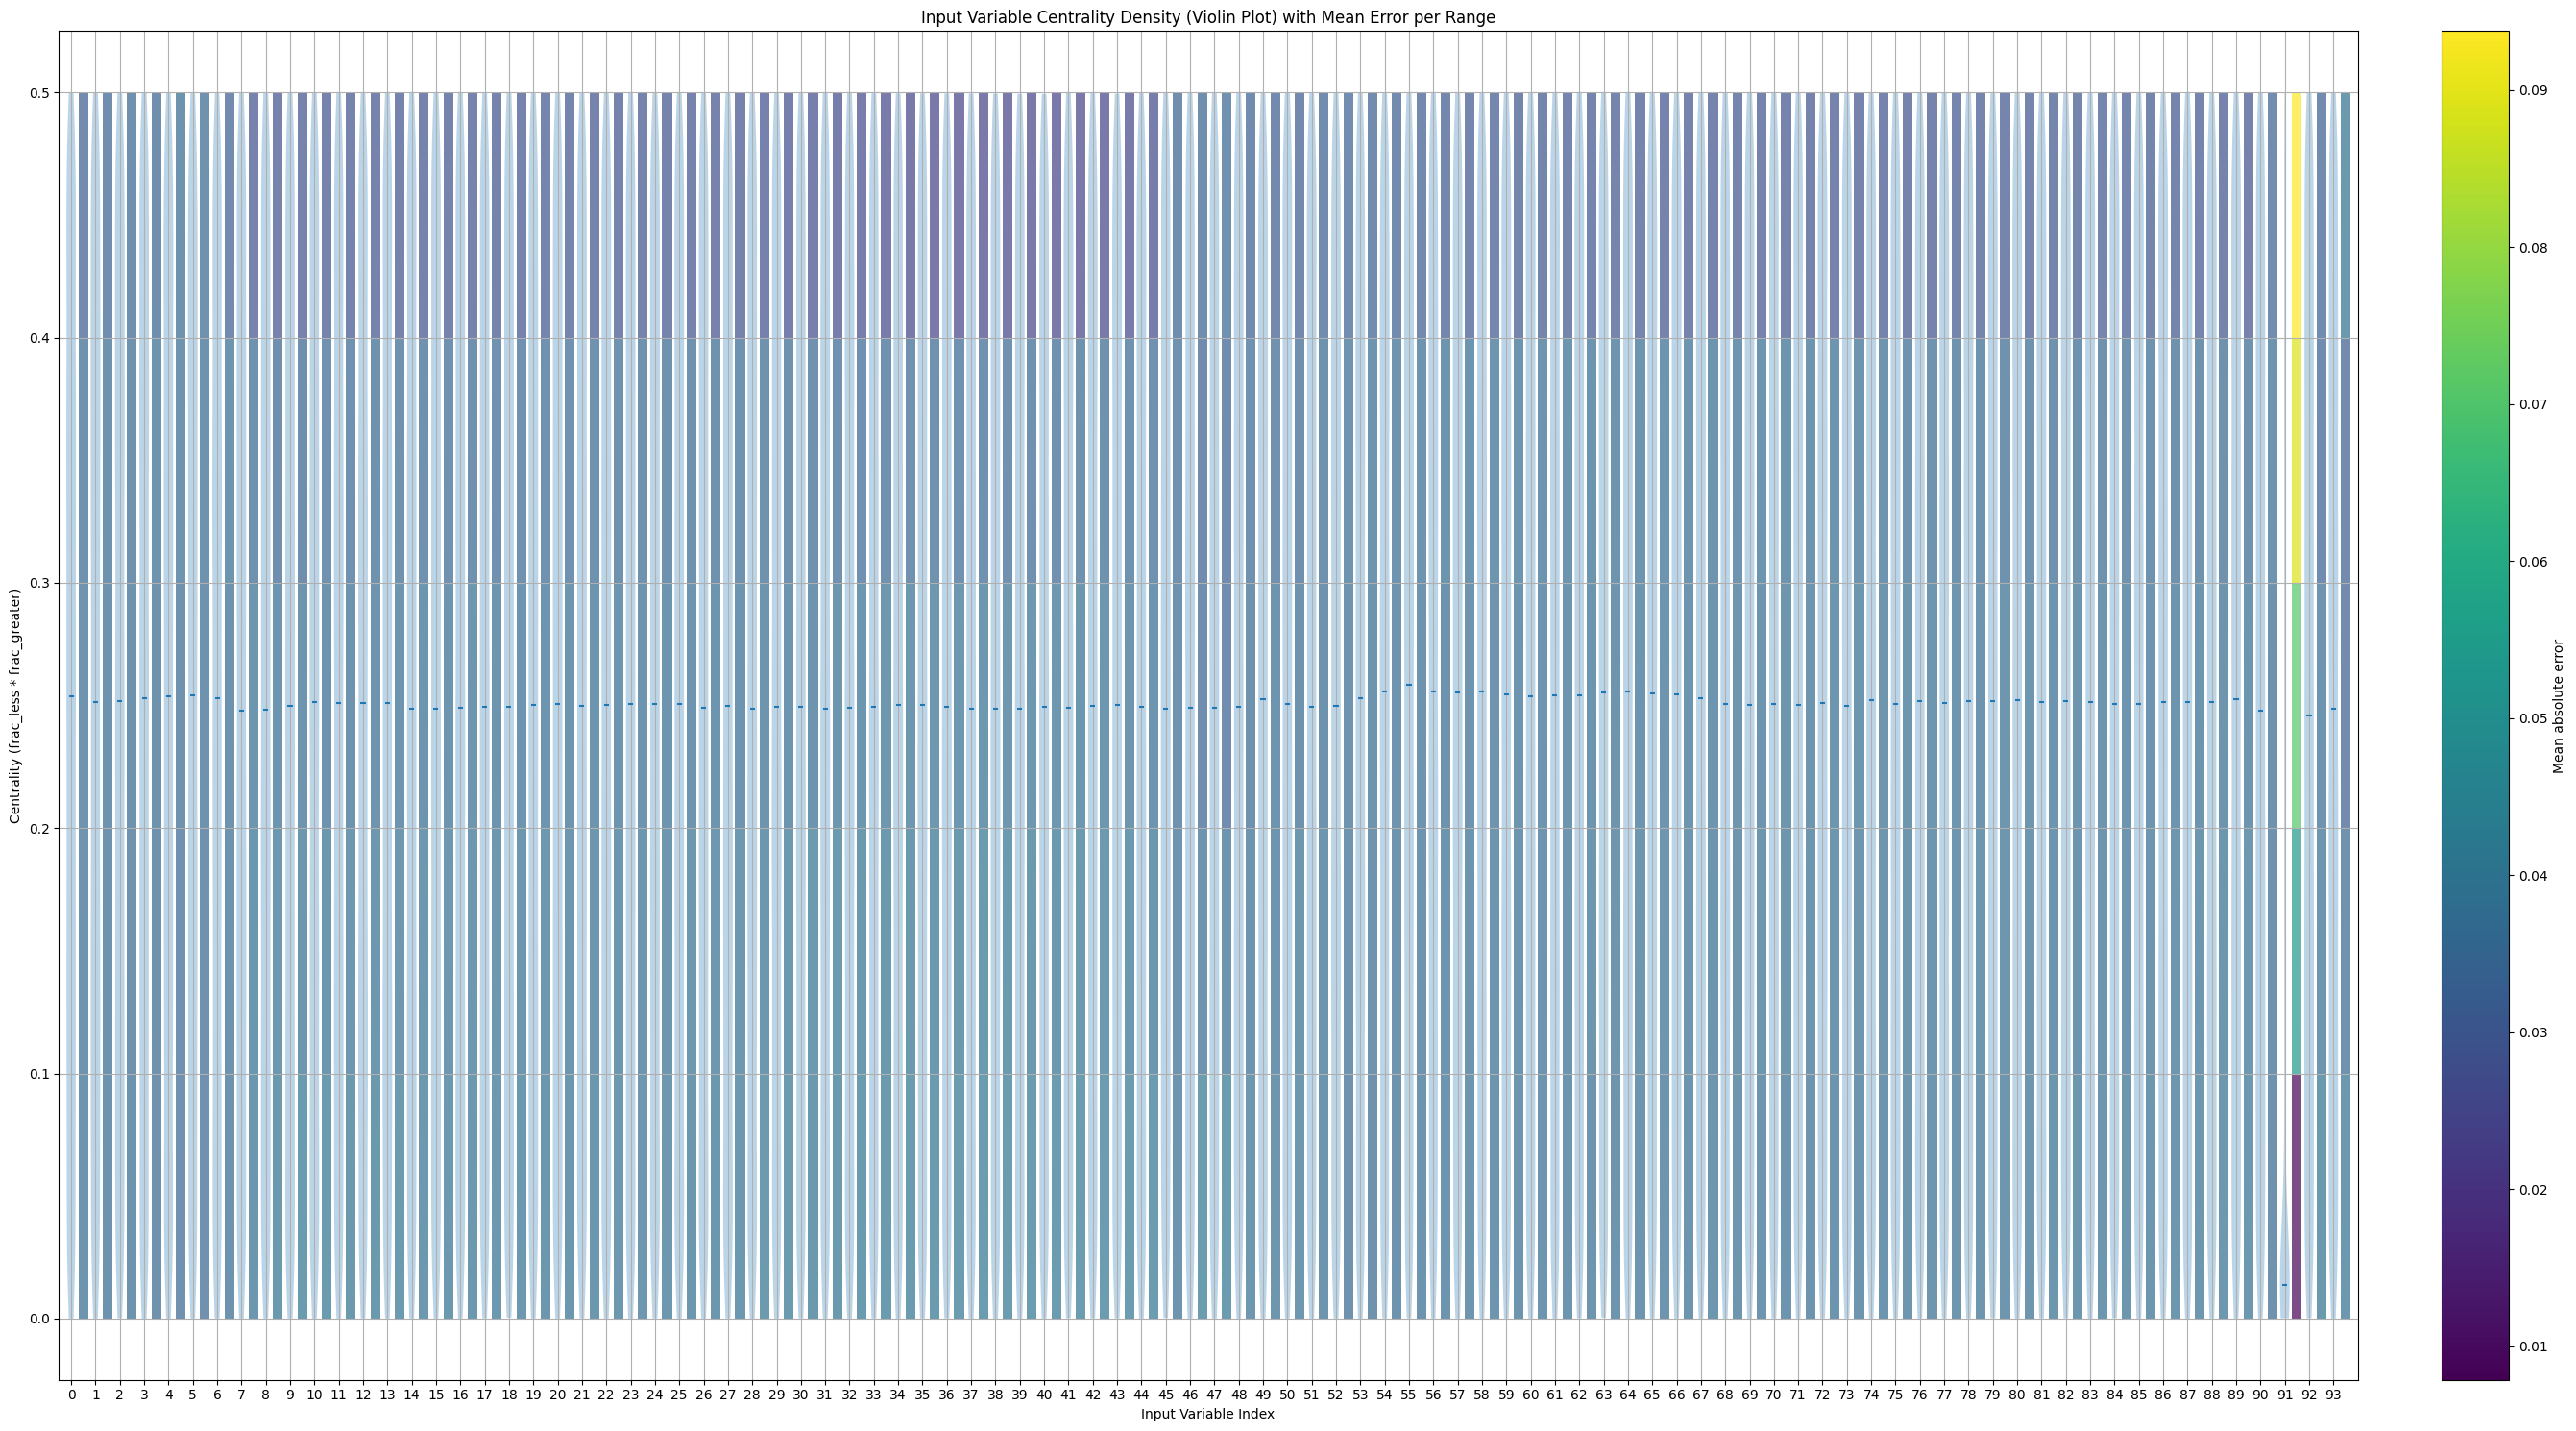

In [29]:
plot_centrality_with_error(son_trained_abs_error, son_trained_percentage_within_array, target_var=90)


Lets try and understand input var 91 more (pbuf_SOLIN - surface incoming solar radiation)
- represents the downward shortwave (solar) radiation reaching the surface

In [30]:
# mam vs son distributions

sample_size = 1000

print(mam_trainset_input.shape)
print(son_trainset_input.shape)

(2325811, 94)
(2300313, 94)


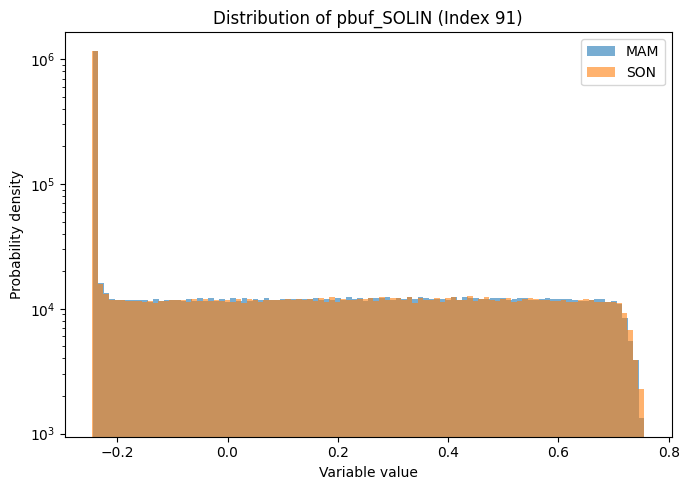

In [31]:
# Extract the variable
mam_vals = mam_trainset_input[:, 91]
son_vals = son_trainset_input[:, 91]

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(mam_vals, bins=100, density=False, alpha=0.6, label='MAM')
ax.hist(son_vals, bins=100, density=False, alpha=0.6, label='SON')
ax.set_yscale('log')
plt.xlabel('Variable value')
plt.ylabel('Probability density')
plt.title('Distribution of pbuf_SOLIN (Index 91)')
plt.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_1296098/3076394372.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mam_vals, son_vals], labels=['MAM', 'SON'], showfliers=False)


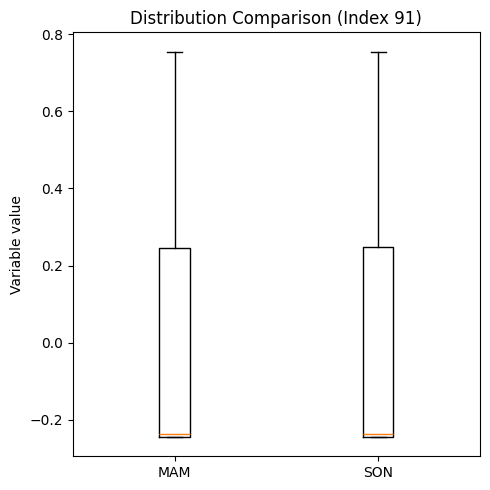

In [32]:
plt.figure(figsize=(5, 5))
plt.boxplot([mam_vals, son_vals], labels=['MAM', 'SON'], showfliers=False)
plt.ylabel('Variable value')
plt.title('Distribution Comparison (Index 91)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1296098/3753666774.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mam_vals, son_vals], labels=['MAM', 'SON'], showfliers=False)


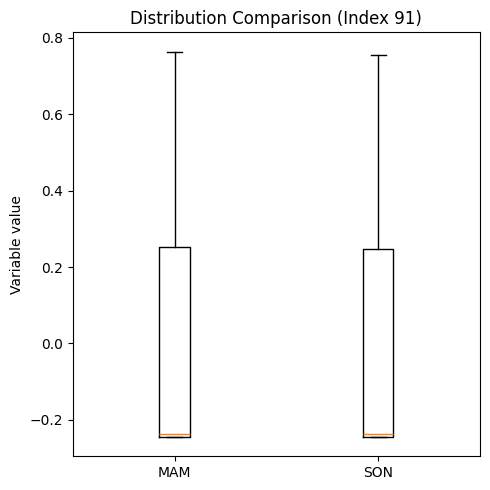

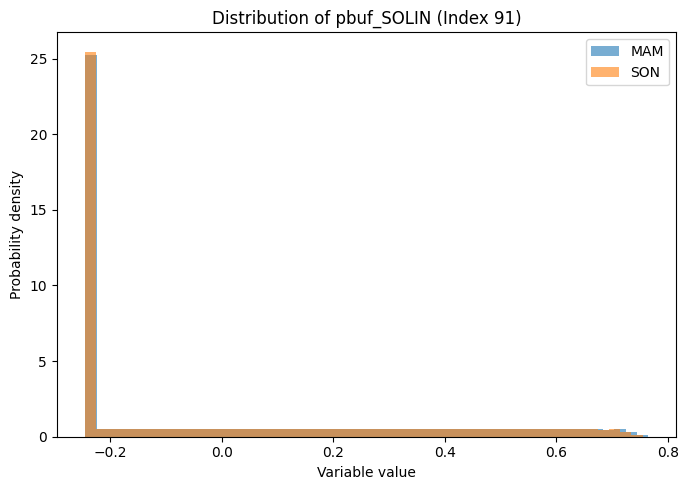

In [33]:
mam_vals = mam_trained_son_input[:, 91]
son_vals = son_trained_son_input[:, 91]

plt.figure(figsize=(5, 5))
plt.boxplot([mam_vals, son_vals], labels=['MAM', 'SON'], showfliers=False)
plt.ylabel('Variable value')
plt.title('Distribution Comparison (Index 91)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

plt.hist(mam_vals, bins=50, density=True, alpha=0.6, label='MAM')
plt.hist(son_vals, bins=50, density=True, alpha=0.6, label='SON')

plt.xlabel('Variable value')
plt.ylabel('Probability density')
plt.title('Distribution of pbuf_SOLIN (Index 91)')
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1296098/3573160349.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mam_trainset_vals, mam_trained_son_vals], labels=['MAM', 'SON'], showfliers=False)


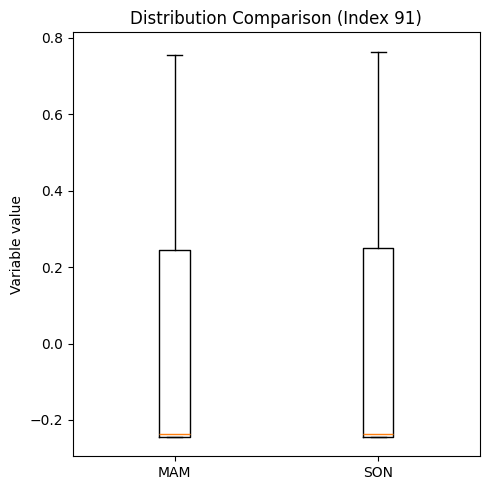

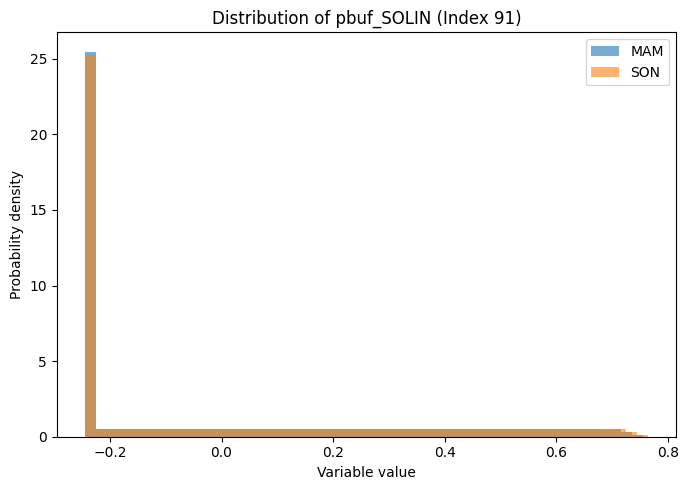

In [34]:
mam_trainset_vals = mam_trainset_input[:, 91]
mam_trained_son_vals = mam_trained_son_input[:, 91]

plt.figure(figsize=(5, 5))
plt.boxplot([mam_trainset_vals, mam_trained_son_vals], labels=['MAM', 'SON'], showfliers=False)
plt.ylabel('Variable value')
plt.title('Distribution Comparison (Index 91)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

plt.hist(mam_trainset_vals, bins=50, density=True, alpha=0.6, label='MAM')
plt.hist(mam_trained_son_vals, bins=50, density=True, alpha=0.6, label='SON')

plt.xlabel('Variable value')
plt.ylabel('Probability density')
plt.title('Distribution of pbuf_SOLIN (Index 91)')
plt.legend()

plt.tight_layout()
plt.show()

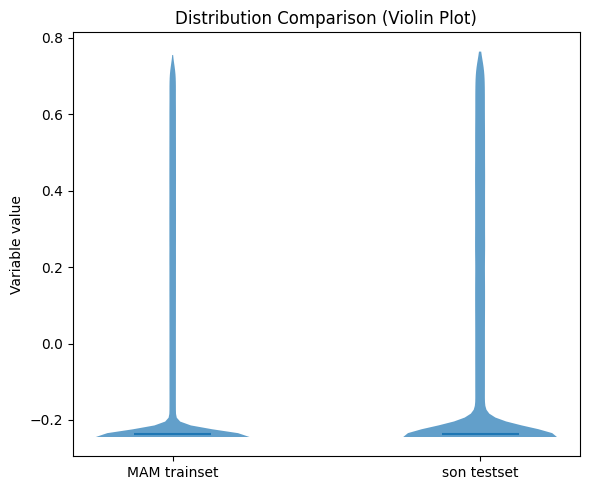

In [57]:


data = [mam_trainset_vals, mam_trained_son_vals]

plt.figure(figsize=(6, 5))
parts = plt.violinplot(
    data,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Style
for pc in parts['bodies']:
    pc.set_alpha(0.7)

plt.xticks([1, 2], ['MAM trainset', 'son testset'])
plt.ylabel('Variable value')
plt.title('Distribution Comparison (Violin Plot)')

plt.tight_layout()
plt.show()


In [39]:
mam_dataset_raw = np.load("/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/MAM/sample_rate_7/input.npy")
print(mam_dataset_raw.shape)

son_dataset_raw = np.load("/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/SON/sample_rate_7/input.npy")
print(son_dataset_raw.shape)

(2907264, 94)
(2875392, 94)


In [52]:
print(f'min: {mam_dataset_raw[:, 91].min()}, max: {mam_dataset_raw[:, 91].max()}')
print(f'min: {son_dataset_raw[:, 91].min()}, max: {son_dataset_raw[:, 91].max()}')

son_sorted = np.sort(son_dataset_raw[:, 91])

# calculate how many son values > than mam's max
num_greater = np.sum(son_sorted > mam_dataset_raw[:, 91].max())
print(f'Number of SON values greater than MAM max: {num_greater} out of {son_sorted.shape[0]}')


print(f'min: {mam_trained_son_input[:, 91].min()}, max: {mam_trained_son_input[:, 91].max()}')
print(f'min: {son_trained_son_input[:, 91].min()}, max: {son_trained_son_input[:, 91].max()}')
print('---')


print(f'min: {mam_trainset_input[:, 91].min()}, max: {mam_trainset_input[:, 91].max()}')
print(f'min: {son_trainset_input[:, 91].min()}, max: {son_trainset_input[:, 91].max()}')

min: 0.0, max: 1384.22021484375
min: 0.0, max: 1396.6697998046875
Number of SON values greater than MAM max: 2136 out of 2875392
min: -0.24461625516414642, max: 0.764255940914154
min: -0.24530723690986633, max: 0.7545721530914307
---
min: -0.24461622536182404, max: 0.7553837299346924
min: -0.2453073114156723, max: 0.7546927332878113


A summary: {'n': 2907264, 'min': np.float32(0.0), 'max': np.float32(1384.2202), 'median': np.float32(10.107306), 'mean': np.float32(338.76172), 'std': np.float32(435.89542), 'p50': np.float32(10.107306), 'p90': np.float32(1078.3582), 'p95': np.float32(1212.7705), 'p99': np.float32(1323.1227), 'p99.9': np.float32(1364.5245)}
B summary: {'n': 2875392, 'min': np.float32(0.0), 'max': np.float32(1396.6698), 'median': np.float32(10.253042), 'mean': np.float32(342.69742), 'std': np.float32(440.92493), 'p50': np.float32(10.253042), 'p90': np.float32(1091.0515), 'p95': np.float32(1227.7216), 'p99': np.float32(1339.7682), 'p99.9': np.float32(1382.698)}


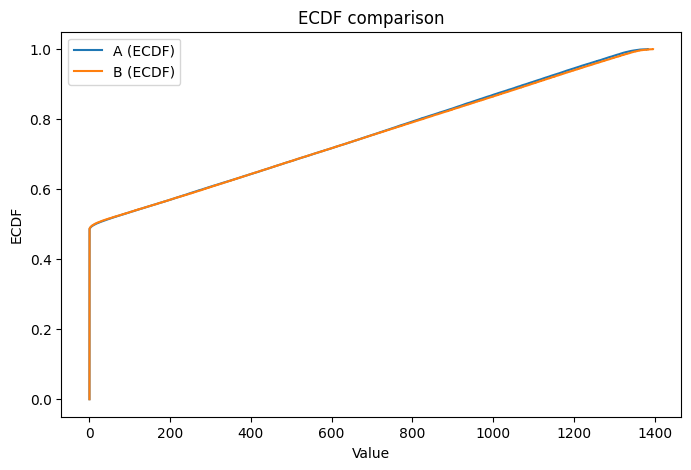

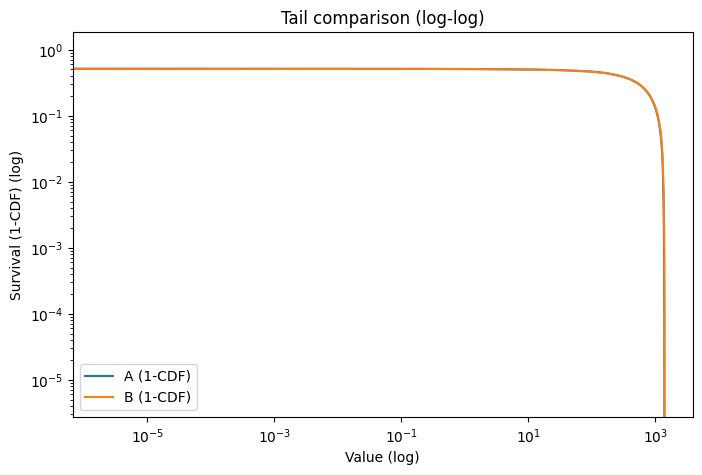

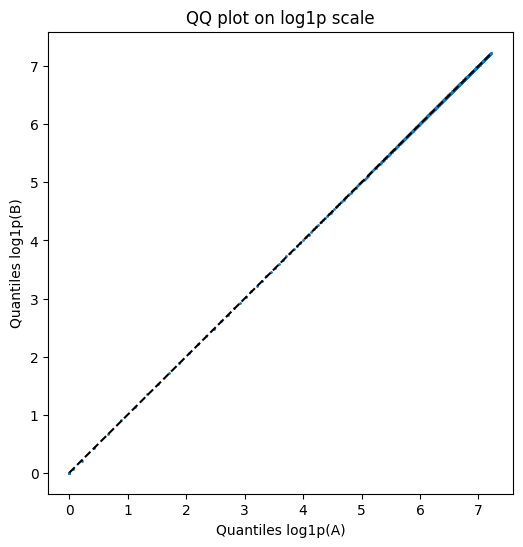

KS test: KstestResult(statistic=np.float64(0.0057823416805006245), pvalue=np.float64(2.0706913105727007e-42), statistic_location=np.float32(1315.2343), statistic_sign=np.int8(1))
Anderson-Darling (subsample): Anderson_ksampResult(statistic=np.float64(13.863604404906006), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=np.float64(0.001))
Mann-Whitney (subsamples): MannwhitneyuResult(statistic=np.float64(19964234249.5), pvalue=np.float64(0.2977982257351306))


/tmp/ipykernel_1296098/73554162.py:93: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_res = stats.anderson_ksamp([a_sub, b_sub])  # use subsamples to keep runtime down


A GPD fit (shape, scale): -0.6551825027590477 112.33458461509821


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

a = mam_dataset_raw[:, 91]  # e.g. variable index 91
b = son_dataset_raw[:, 91]  # e.g. variable index 91

# === assume a and b are your numpy arrays ===
# a = np.load("a.npy"); b = np.load("b.npy")
# For safe transforms use positive data assumption; if zeros exist use log1p

def summary_stats(x, ps=(50,90,95,99,99.9)):
    out = {"n": x.size, "min": x.min(), "max": x.max(), "median": np.median(x),
           "mean": np.mean(x), "std": np.std(x)}
    out.update({f"p{p}": np.percentile(x, p) for p in ps})
    return out

# compute and print summaries (fast even for millions)
print("A summary:", summary_stats(a))
print("B summary:", summary_stats(b))

# ========== ECDF (plot) ==========
def ecdf(x):
    x_sorted = np.sort(x)
    y = np.arange(1, x_sorted.size+1) / x_sorted.size
    return x_sorted, y

# Subsample for plotting to keep plots snappy (optional)
def subsample(x, n=200000, rng=None):
    if x.size <= n:
        return x
    rng = np.random.default_rng(rng)
    return x[rng.choice(x.size, n, replace=False)]

a_sub = subsample(a)
b_sub = subsample(b)

xa, ya = ecdf(a_sub)
xb, yb = ecdf(b_sub)

plt.figure(figsize=(8,5))
plt.step(xa, ya, where='post', label='A (ECDF)')
plt.step(xb, yb, where='post', label='B (ECDF)')
plt.xscale('linear')   # try 'log' too if distribution is strongly skewed
plt.xlabel('Value')
plt.ylabel('ECDF')
plt.legend()
plt.title('ECDF comparison')
plt.show()

# ========== Complementary CDF (survival) on log-log ==========
def comp_ccdf(x, subs=200000):
    xs = np.sort(subsample(x, subs))
    ccdf = 1.0 - np.arange(1, xs.size+1) / xs.size
    return xs, ccdf

xa, ccdfa = comp_ccdf(a)
xb, ccfdb = comp_ccdf(b)

plt.figure(figsize=(8,5))
plt.loglog(xa, ccdfa, label='A (1-CDF)')
plt.loglog(xb, ccfdb, label='B (1-CDF)')
plt.xlabel('Value (log)')
plt.ylabel('Survival (1-CDF) (log)')
plt.legend()
plt.title('Tail comparison (log-log)')
plt.show()

# ========== QQ plot on log-scale ==========
# take log1p to avoid -inf for zeros
la = np.log1p(a)
lb = np.log1p(b)
# sample quantiles
qs = np.linspace(0.001, 0.999, 1000)
qa = np.quantile(la, qs)
qb = np.quantile(lb, qs)

plt.figure(figsize=(6,6))
plt.plot(qa, qb, '.', markersize=2)
mn = min(qa.min(), qb.min()); mx = max(qa.max(), qb.max())
plt.plot([mn,mx], [mn,mx], 'k--')
plt.xlabel('Quantiles log1p(A)')
plt.ylabel('Quantiles log1p(B)')
plt.title('QQ plot on log1p scale')
plt.show()

# ========== Formal tests (use with care) ==========
# 2-sample KS (sensitive to any difference; with millions of points p is near zero for tiny diffs)
ks_res = stats.ks_2samp(a, b, alternative='two-sided', mode='asymp')
print("KS test:", ks_res)

# Anderson-Darling k-sample (scipy's anderson_ksamp)
ad_res = stats.anderson_ksamp([a_sub, b_sub])  # use subsamples to keep runtime down
print("Anderson-Darling (subsample):", ad_res)

# Mann-Whitney U (shift test) - use random subsample to keep time/memory small
s1 = subsample(a, n=200000, rng=1)
s2 = subsample(b, n=200000, rng=2)
mw = stats.mannwhitneyu(s1, s2, alternative='two-sided')
print("Mann-Whitney (subsamples):", mw)

# ========== Tail fit: fit generalized Pareto above a threshold ==========
# pick threshold as e.g. 95th percentile
thr = np.percentile(a, 95)
tail = a[a > thr] - thr
# fit GPD to tail of A
c, loc, scale = stats.genpareto.fit(tail, floc=0)  # shape c, scale
print("A GPD fit (shape, scale):", c, scale)
# repeat for B similarly...


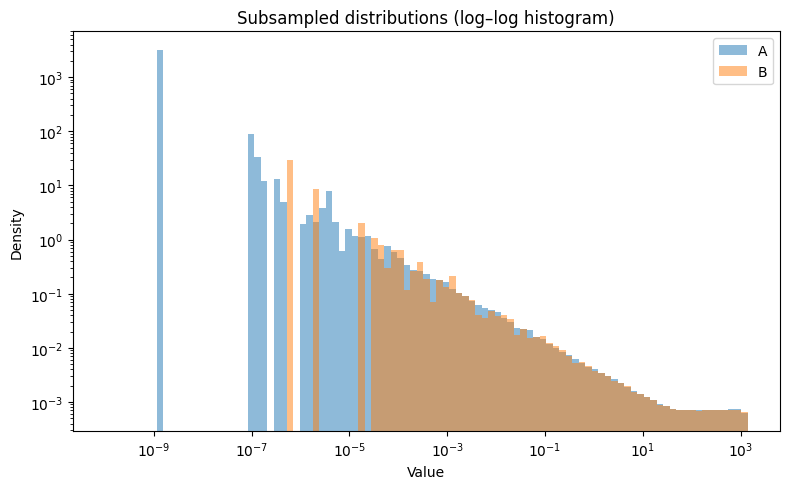

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def subsample(x, n=20000000, seed=0):
    if x.size <= n:
        return x
    rng = np.random.default_rng(seed)
    return x[rng.choice(x.size, n, replace=False)]

a_s = subsample(a, seed=1)
b_s = subsample(b, seed=2)

# log-spaced bins
xmin = min(a_s.min(), b_s.min())
xmax = max(a_s.max(), b_s.max())
bins = np.logspace(np.log10(xmin + 1e-10), np.log10(xmax), 100)

plt.figure(figsize=(8,5))
plt.hist(a_s, bins=bins, density=True, alpha=0.5, label="A")
plt.hist(b_s, bins=bins, density=True, alpha=0.5, label="B")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Subsampled distributions (log–log histogram)")
plt.legend()
plt.tight_layout()
plt.show()


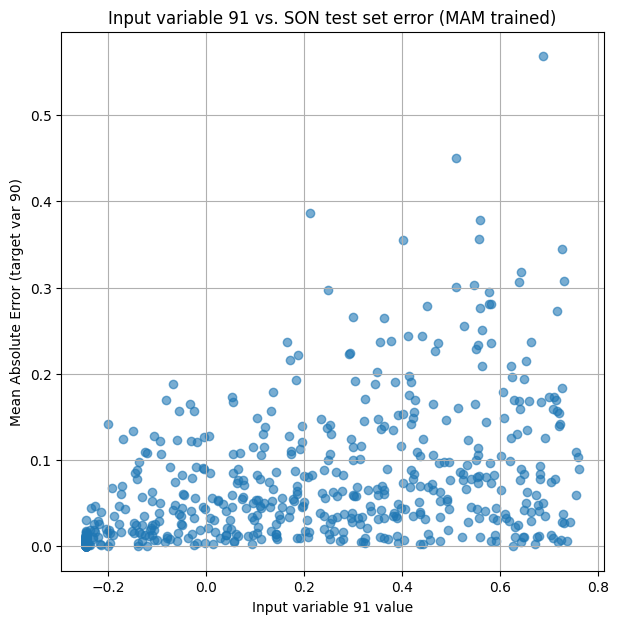

In [55]:
sample_size = 1000
rnd = np.random.default_rng(seed=42).choice(
    mam_trained_percentage_within_array.shape[0],
    size=sample_size,
    replace=False
)

error = mam_trained_abs_error[:, 90]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(mam_trained_son_input[:, 91][rnd], error[rnd], alpha=0.6)
ax.set_xlabel('Input variable 91 value')
ax.set_ylabel('Mean Absolute Error (target var 90)')
ax.set_title('Input variable 91 vs. SON test set error (MAM trained)')
ax.grid(True)
plt.show()




In [69]:

# Extract the feature
x = mam_dataset_raw[:, 91]



# Identify the spike (mode)
spike_value = np.median(x[x < 20])  # robust for your plot
print("Spike value:", spike_value)

is_spike = (x == spike_value)


Spike value: 0.0


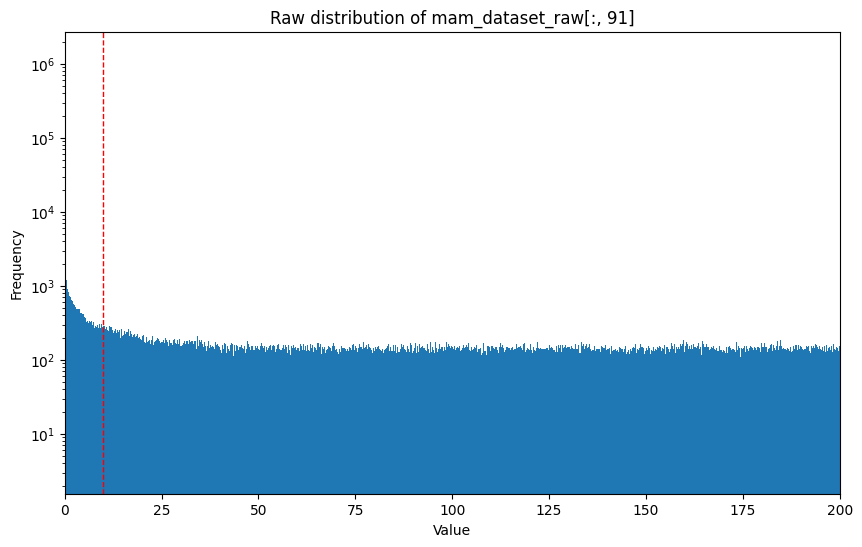

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(x, bins=10000)
ax.set_yscale('log')
plt.title("Raw distribution of mam_dataset_raw[:, 91]")
ax.axvline(10, color='red', linestyle='dashed', linewidth=1)
plt.xlabel("Value")
plt.ylabel("Frequency")
ax.set_xlim(left=0, right=200)
plt.show()
